<a href="https://colab.research.google.com/github/augustolengua/augustolengua/blob/main/2026_CON_VELOCIDAD_20_Modelo_Predictivo_Fidelizacion_FINAL_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install kmodes

In [2]:
pip install gower

In [3]:
import pandas as pd
import numpy as np
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import gower
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
import joblib

# Lectura y limpieza

In [4]:
df = pd.read_excel('BD_medicos.xlsx', sheet_name='BD Medicos')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26900 entries, 0 to 26899
Data columns (total 29 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id_medico                            26900 non-null  int64  
 1   documento                            26900 non-null  object 
 2   reporte                              26875 non-null  object 
 3   numero_colegiatura                   26881 non-null  float64
 4   Recuento de id_ingreso               26900 non-null  int64  
 5   Análisis01                           26900 non-null  int64  
 6   Pacientes                            26900 non-null  int64  
 7   Fecha 1º atencion medico             26900 non-null  object 
 8   Fecha Uº atencion medico             26900 non-null  object 
 9   Produccion Neta sin IGV              26900 non-null  int64  
 10  Producción Bruta Sin IGV             26900 non-null  int64  
 11  Pacientes nuevos 2024       

In [5]:
df.describe()

,id_medico,numero_colegiatura,Recuento de id_ingreso,Análisis01,Pacientes,Produccion Neta sin IGV,Producción Bruta Sin IGV,Pacientes nuevos 2024,Edad_medico,Examenes por atencion,Atenciones por paciente,Descuento de sus Atenciones,Antiguedad del mèdico anios con roe,Tasa de pacientes nuevos 2024,Produccion neta por atencion,Usa descuento,latitud,longitud
count,26900.000000,26881.000000,26900.000000,26900.000000,26900.000000,2.690000e+04,2.690000e+04,18171.000000,22278.000000,26900.000000,26900.000000,26900.000000,26900.000000,26900.000000,26900.000000,26900.000000,21966.000000,21966.000000
mean,29789.303271,48092.362524,11.896134,46.500558,8.527286,2.979825e+03,3.415518e+03,4.829454,50.916914,3.411933,1.282193,0.251641,11.253866,0.430259,207.822379,1.354201,-12.076950,-76.956023
std,16020.585917,26083.686711,112.621804,346.246551,92.104381,2.326871e+04,2.554729e+04,39.484418,13.691083,2.465558,0.716336,4.941928,9.505713,0.385408,192.957336,3.799891,0.848009,4.763712
min,3.000000,0.000000,1.000000,1.000000,1.000000,0.000000e+00,1.500000e+01,1.000000,-46.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-33.319520,-770.290000
25%,16760.000000,26894.000000,1.000000,3.000000,1.000000,1.800000e+02,2.190000e+02,1.000000,39.000000,2.000000,1.000000,0.040000,4.000000,0.000000,93.000000,0.000000,-12.095767,-77.053394
50%,29834.000000,46497.000000,3.000000,9.000000,2.000000,5.150000e+02,6.240000e+02,2.000000,49.000000,3.000000,1.000000,0.190000,9.000000,0.400000,160.000000,0.000000,-12.065878,-77.034407
75%,43748.750000,67867.000000,8.000000,25.000000,6.000000,1.525000e+03,1.801000e+03,4.000000,61.000000,4.000000,1.000000,0.340000,16.000000,0.750000,258.000000,1.000000,-12.041037,-76.998507
max,55682.000000,999999.000000,17245.000000,37853.000000,14572.000000,2.311434e+06,2.531326e+06,5180.000000,126.000000,36.000000,26.000000,799.000000,33.000000,1.000000,4472.000000,114.000000,42.812526,-1.645774


In [6]:
# Filtramos columnas que no sirven
df= df.drop(['documento', 'reporte',], axis=1)
df = df.drop(['numero_colegiatura','Direccion'], axis=1)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26900 entries, 0 to 26899
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id_medico                            26900 non-null  int64  
 1   Recuento de id_ingreso               26900 non-null  int64  
 2   Análisis01                           26900 non-null  int64  
 3   Pacientes                            26900 non-null  int64  
 4   Fecha 1º atencion medico             26900 non-null  object 
 5   Fecha Uº atencion medico             26900 non-null  object 
 6   Produccion Neta sin IGV              26900 non-null  int64  
 7   Producción Bruta Sin IGV             26900 non-null  int64  
 8   Pacientes nuevos 2024                18171 non-null  float64
 9   id_sexo                              26782 non-null  object 
 10  Edad_medico                          22278 non-null  float64
 11  Colegio                     

In [8]:
#df= df[df['numero_colegiatura']!=999999]
df = df[df['id_medico']!='Filtros aplicados: \nnombre no es ME\nAño es 2024\nnombre es DOMICILIOS, PARTICULARES, WEB CARRITO DOM o WEB CARRITO SEDE']
df = df[df['id_medico']!='Total']
df = df[df['id_medico']!=53183] # USER TESTING
df = df[df['id_medico']!=42562] # USER TESTING
df = df[df['id_medico']!=53033] # USER TESTING
df = df[df['id_medico']!=19407] # Dr Juan Carlos
df = df[df['id_medico']!=44760] # Dr Yoshie Higuchi
df=df[~df['Centro de trabajo'].isin(['CLINICA SAN FELIPE','CLINICA SAN FELIPE TORRE I','CLINICA SAN FELIPE TORRE II','CLINICA SAN FELIPE EDIFICIO A','CLINICA SAN FELIPE EDIFICIO B','CONSULTORIO MEDICO "SAN FELIPE"','LABORATORIO ROE SAN FELIPE','SOLIDARIDAD SAN FELIPE','CLINICA SAN FELIPE LA MOLINA'])]
#df = df[df['Direccion']!=0]
#df = df[~df['Direccion'].isna()]

In [9]:
df = df[df['Edad_medico']>10]
df = df[df['Especialidad']!=0]
mapa_categorias = {
    1: 'Hospitales MINSA',
    2: 'Hospitales ESSALUD',
    3: 'Clínicas privadas (Red de Seguros)',
    4: 'Clínicas privadas (No red de Seguros)',
    5: 'Postas del MINSA',
    6: 'Centros de Salud Municipales',
    7: 'Otros',
    8: 'Consultorio Particular',
    9: 'Hospitales FAP',
    10: 'Hospitales Militares',
    11: 'Hospitales Navales',
    12: 'Hospitales de Policía',
    13: 'CAFAE'
}

# 2. Suponiendo que tu columna se llama 'Categoria_Numerica'
# Primero nos aseguramos que sea número (por si tienes textos '1' mezclados con números 1)
df['Categoria'] = pd.to_numeric(df['Categoria'], errors='coerce')

# 3. Aplicamos el cambio
df['Categoria'] = df['Categoria'].map(mapa_categorias)

# Distancias más cortas

In [10]:
df_sedes = pd.read_excel('BD_medicos.xlsx', sheet_name='Hoja 6')
df_sedes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sedes roe  40 non-null     object 
 1   Latitude   40 non-null     float64
 2   Longitude  40 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.1+ KB


In [11]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist # Herramienta para calcular distancias eficientemente

def calcular_distancia_minima_a_sedes(df, df_sedes):
    R = 6371 # Radio de la Tierra en km

    lat_medicos = np.deg2rad(df['latitud'].values)
    lon_medicos = np.deg2rad(df['longitud'].values)
    coords_medicos = np.stack([lat_medicos, lon_medicos], axis=1)

    lat_sedes = np.deg2rad(df_sedes['Latitude'].values)
    lon_sedes = np.deg2rad(df_sedes['Longitude'].values)
    coords_sedes = np.stack([lat_sedes, lon_sedes], axis=1)

    def haversine_dist(u, v):
        dlat = v[0] - u[0]
        dlon = v[1] - u[1]
        a = np.sin(dlat / 2)**2 + np.cos(u[0]) * np.cos(v[0]) * np.sin(dlon / 2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        return R * c

    distancias_matriz = cdist(coords_medicos, coords_sedes, metric=haversine_dist)
    distancia_minima_km = np.min(distancias_matriz, axis=1)

    # Devolvemos una Serie con el mismo índice que el DataFrame de entrada
    return pd.Series(distancia_minima_km, index=df.index)
# -------------------------------------------------------------------------------------------------

In [12]:
distancias_minimas = calcular_distancia_minima_a_sedes(df, df_sedes)

# Asignamos la Serie como una nueva columna en el DataFrame principal (df)
df['Distancia'] = distancias_minimas

# --- 3. RESULTADO FINAL ---

print("\n--- DataFrame Principal con la Distancia Mínima Añadida ---")
print(df)


--- DataFrame Principal con la Distancia Mínima Añadida ---
       id_medico  Recuento de id_ingreso  Análisis01  Pacientes  \
0              3                     137         626         76   
2             10                       5          14          5   
4             18                      67         309         40   
5             20                      90         259         67   
6             21                     277        1182        178   
...          ...                     ...         ...        ...   
26616      55261                       1           1          1   
26626      55274                       1          10          1   
26717      55423                       1           3          1   
26718      55425                       1           2          1   
26820      55585                       3           7          2   

                 Fecha 1º atencion medico           Fecha Uº atencion medico  \
0         jueves, 10 de Diciembre de 1992     lunes, 1

# Nuevas variables

In [13]:
# leer archivo excel
velocidad = pd.read_excel('cantidades medicos fidelizacion.xlsx')
velocidad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42578 entries, 0 to 42577
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id_medico  42578 non-null  int64  
 1   c2017      42578 non-null  int64  
 2   c2018      42578 non-null  int64  
 3   c2019      42578 non-null  int64  
 4   c2020      42578 non-null  int64  
 5   c2021      42578 non-null  int64  
 6   c2022      42578 non-null  int64  
 7   c2023      42578 non-null  int64  
 8   c2024      42578 non-null  int64  
 9   c2025      42578 non-null  float64
 10  BD         26900 non-null  float64
dtypes: float64(2), int64(9)
memory usage: 3.6 MB


In [14]:
velocidad.head()

,id_medico,c2017,c2018,c2019,c2020,c2021,c2022,c2023,c2024,c2025,BD
0,1,18,2,1,1,2,1,0,0,0.000000,NaN
1,2,0,0,1,4,0,0,0,0,0.000000,NaN
2,3,134,111,118,97,152,128,130,142,112.363636,3.0
3,4,0,0,0,0,0,0,0,1,0.000000,NaN
4,5,84,84,80,57,57,76,74,66,44.727273,5.0


In [15]:
cols_anos = ['c2017', 'c2018', 'c2019', 'c2020', 'c2021', 'c2022', 'c2023', 'c2024']

# 3. Calculamos la diferencia (Año actual - Año anterior)
# axis=1 indica que la operación es horizontal (entre columnas)
df_variacion = velocidad[cols_anos].diff(axis=1)

# Eliminamos la columna c2017 porque da NaN (no hay año 2016 para restar)
df_variacion = df_variacion.drop(columns=['c2017'])

# (Opcional) Renombramos las columnas para que se entienda que es variación
# Esto cambiará los nombres a 'var_c2018', 'var_c2019', etc.
df_variacion.columns = ['var_' + col for col in df_variacion.columns]

# 4. Calculamos el PROMEDIO de esas variaciones numéricas
velocidad['promedio_variacion_anual'] = df_variacion.mean(axis=1)

# 5. Unimos todo para ver el resultado final
resultado_final = pd.concat([velocidad[['id_medico']], df_variacion, velocidad[['promedio_variacion_anual']]], axis=1)

print(resultado_final)

       id_medico  var_c2018  var_c2019  var_c2020  var_c2021  var_c2022  \
0              1        -16         -1          0          1         -1   
1              2          0          1          3         -4          0   
2              3        -23          7        -21         55        -24   
3              4          0          0          0          0          0   
4              5          0         -4        -23          0         19   
...          ...        ...        ...        ...        ...        ...   
42573      55680          0          0          0          0          0   
42574      55681          0          0          0          0          0   
42575      55682          0          0          0          0          0   
42576      56854          0          0          0          0          0   
42577      58916          0          0          0          0          0   

       var_c2023  var_c2024  promedio_variacion_anual  
0             -1          0                

In [16]:
velocidad = velocidad.drop('promedio_variacion_anual',axis=1)
#convertir a entero
velocidad['c2025'] = velocidad['c2025'].astype(int)
velocidad

,id_medico,c2017,c2018,c2019,c2020,c2021,c2022,c2023,c2024,c2025,BD
0,1,18,2,1,1,2,1,0,0,0,NaN
1,2,0,0,1,4,0,0,0,0,0,NaN
2,3,134,111,118,97,152,128,130,142,112,3.0
3,4,0,0,0,0,0,0,0,1,0,NaN
4,5,84,84,80,57,57,76,74,66,44,5.0
...,...,...,...,...,...,...,...,...,...,...,...
42573,55680,0,0,0,0,0,0,0,1,0,55680.0
42574,55681,0,0,0,0,0,0,0,1,1,55681.0
42575,55682,0,0,0,0,0,0,0,1,1,55682.0
42576,56854,0,0,0,0,0,0,1,0,3,NaN


In [17]:
resultado_final = resultado_final[['id_medico','var_c2024','promedio_variacion_anual']]
resultado_final

,id_medico,var_c2024,promedio_variacion_anual
0,1,0,-2.571429
1,2,0,0.000000
2,3,12,1.142857
3,4,1,0.142857
4,5,-8,-2.571429
...,...,...,...
42573,55680,1,0.142857
42574,55681,1,0.142857
42575,55682,1,0.142857
42576,56854,-1,0.000000


## Variacion Porcentual

In [18]:
# leer archivo excel
velocidad = pd.read_excel('cantidades medicos fidelizacion.xlsx')
velocidad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42578 entries, 0 to 42577
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id_medico  42578 non-null  int64  
 1   c2017      42578 non-null  int64  
 2   c2018      42578 non-null  int64  
 3   c2019      42578 non-null  int64  
 4   c2020      42578 non-null  int64  
 5   c2021      42578 non-null  int64  
 6   c2022      42578 non-null  int64  
 7   c2023      42578 non-null  int64  
 8   c2024      42578 non-null  int64  
 9   c2025      42578 non-null  float64
 10  BD         26900 non-null  float64
dtypes: float64(2), int64(9)
memory usage: 3.6 MB


In [19]:
import pandas as pd
import numpy as np

# 1. Definimos las columnas de años en orden
cols_anos = ['c2017', 'c2018', 'c2019', 'c2020', 'c2021', 'c2022', 'c2023', 'c2024']

# 2. CALCULAR VARIACIÓN PORCENTUAL (pct_change)
# Esto hace: (Año Actual - Año Anterior) / Año Anterior
# axis=1 es clave para hacerlo horizontalmente
df_pct = velocidad[cols_anos].pct_change(axis=1)

# 3. LIMPIEZA
# Eliminamos la primera columna (c2017) porque siempre será NaN (no tiene previo)
df_pct = df_pct.drop(columns=['c2017'])

# Reemplazamos infinitos (división por cero) si un médico tenía 0 en un año
df_pct = df_pct.replace([np.inf, -np.inf], np.nan)

# (Opcional) Renombramos columnas para referencia
df_pct.columns = ['pct_' + col for col in df_pct.columns]

# 4. CALCULAR PROMEDIO
# Multiplicamos por 100 para verlo como porcentaje (ej. 15.5%)
velocidad['promedio_porcentual'] = df_pct.mean(axis=1) * 100

# 5. RESULTADO FINAL
# Rellenamos NaN con 0 (para médicos que no tuvieron actividad o división por cero)
velocidad['promedio_porcentual'] = velocidad['promedio_porcentual'].fillna(0)

print("--- Ejemplo de Resultados ---")
cols_mostrar = ['id_medico', 'c2017', 'c2024', 'promedio_porcentual']
print(velocidad[cols_mostrar].head())

--- Ejemplo de Resultados ---
   id_medico  c2017  c2024  promedio_porcentual
0          1     18      0           -31.481481
1          2      0      0           100.000000
2          3    134    142             3.292906
3          4      0      1             0.000000
4          5     84     66            -1.945852


In [20]:
porcentual = velocidad[['id_medico','promedio_porcentual']]
porcentual

,id_medico,promedio_porcentual
0,1,-31.481481
1,2,100.000000
2,3,3.292906
3,4,0.000000
4,5,-1.945852
...,...,...
42573,55680,0.000000
42574,55681,0.000000
42575,55682,0.000000
42576,56854,-100.000000


In [21]:
# leer archivo excel
target = pd.read_excel('cantidades medicos fidelizacion.xlsx')
target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42578 entries, 0 to 42577
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id_medico  42578 non-null  int64  
 1   c2017      42578 non-null  int64  
 2   c2018      42578 non-null  int64  
 3   c2019      42578 non-null  int64  
 4   c2020      42578 non-null  int64  
 5   c2021      42578 non-null  int64  
 6   c2022      42578 non-null  int64  
 7   c2023      42578 non-null  int64  
 8   c2024      42578 non-null  int64  
 9   c2025      42578 non-null  float64
 10  BD         26900 non-null  float64
dtypes: float64(2), int64(9)
memory usage: 3.6 MB


In [22]:
target = target[['id_medico','c2024','c2025']]
target['c2025']= target['c2025'].astype(int)
target['v_2025']=target['c2025']-target['c2024']
target = target[['id_medico','v_2025']]
target

,id_medico,v_2025
0,1,0
1,2,0
2,3,-30
3,4,-1
4,5,-22
...,...,...
42573,55680,-1
42574,55681,0
42575,55682,0
42576,56854,3


In [23]:
resultado_final = pd.merge(
    resultado_final,                    # DataFrame de la izquierda (el principal)
    target,               # DataFrame de la derecha (el que tiene la info extra)
    left_on='id_medico',         # Columna del DF de la izquierda a usar para la unión
    right_on='id_medico',            # Indica que el DF de la derecha debe usar su INDEX para la unión
    how='left'                   # Tipo de unión (left mantiene todas las filas de df_datos)
)

In [24]:
df = pd.merge(
    df,                    # DataFrame de la izquierda (el principal)
    velocidad,               # DataFrame de la derecha (el que tiene la info extra)
    left_on='id_medico',         # Columna del DF de la izquierda a usar para la unión
    right_on='id_medico',            # Indica que el DF de la derecha debe usar su INDEX para la unión
    how='left'                   # Tipo de unión (left mantiene todas las filas de df_datos)
)

In [25]:
velocidad = resultado_final
velocidad['aceleracion']=velocidad['var_c2024']-velocidad['promedio_variacion_anual']
velocidad

,id_medico,var_c2024,promedio_variacion_anual,v_2025,aceleracion
0,1,0,-2.571429,0,2.571429
1,2,0,0.000000,0,0.000000
2,3,12,1.142857,-30,10.857143
3,4,1,0.142857,-1,0.857143
4,5,-8,-2.571429,-22,-5.428571
...,...,...,...,...,...
42573,55680,1,0.142857,-1,0.857143
42574,55681,1,0.142857,0,0.857143
42575,55682,1,0.142857,0,0.857143
42576,56854,-1,0.000000,3,-1.000000


In [26]:
df = pd.merge(
    df,                    # DataFrame de la izquierda (el principal)
    velocidad,               # DataFrame de la derecha (el que tiene la info extra)
    left_on='id_medico',         # Columna del DF de la izquierda a usar para la unión
    right_on='id_medico',            # Indica que el DF de la derecha debe usar su INDEX para la unión
    how='left'                   # Tipo de unión (left mantiene todas las filas de df_datos)
)

In [27]:
# df = pd.merge(
#     df,                    # DataFrame de la izquierda (el principal)
#     porcentual,               # DataFrame de la derecha (el que tiene la info extra)
#     left_on='id_medico',         # Columna del DF de la izquierda a usar para la unión
#     right_on='id_medico',            # Indica que el DF de la derecha debe usar su INDEX para la unión
#     how='left'                   # Tipo de unión (left mantiene todas las filas de df_datos)
# )

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21943 entries, 0 to 21942
Data columns (total 41 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id_medico                            21943 non-null  int64  
 1   Recuento de id_ingreso               21943 non-null  int64  
 2   Análisis01                           21943 non-null  int64  
 3   Pacientes                            21943 non-null  int64  
 4   Fecha 1º atencion medico             21943 non-null  object 
 5   Fecha Uº atencion medico             21943 non-null  object 
 6   Produccion Neta sin IGV              21943 non-null  int64  
 7   Producción Bruta Sin IGV             21943 non-null  int64  
 8   Pacientes nuevos 2024                14902 non-null  float64
 9   id_sexo                              21899 non-null  object 
 10  Edad_medico                          21943 non-null  float64
 11  Colegio                     

In [29]:
df =df.drop(['Pacientes','Fecha 1º atencion medico','Fecha Uº atencion medico','Produccion Neta sin IGV','Producción Bruta Sin IGV','Pacientes nuevos 2024','Examenes por atencion','Atenciones por paciente','Descuento de sus Atenciones',
             'Tasa de pacientes nuevos 2024','Produccion neta por atencion','Usa descuento','latitud','longitud','Centro de trabajo'],axis=1)
#df[['id_medico','Pacientes nuevos 2024','id_sexo','Edad_medico','Colegio','Especialidad','Antiguedad del mèdico anios con roe','Categoria','Distancia','var_c2024','promedio_variacion_anual','aceleracion','v_2025']]

In [30]:
cambios = {
    'Análisis01': 'Analisis',
    'Antiguedad del mèdico anios con roe':'Antiguedad'
}

# Aplicar el cambio y guardar el resultado
df = df.rename(columns=cambios)

In [31]:
df['Vigencia']=80-df['Edad_medico']

## NSE

In [32]:
nse = pd.read_excel('NSE.xlsx')
nse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233445 entries, 0 to 233444
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   fk_id_medico           233445 non-null  int64  
 1   fk_id_paciente         233410 non-null  float64
 2   paciente_distrito      230554 non-null  object 
 3   paciente_departamento  230554 non-null  object 
 4   atencion_procedencia   233445 non-null  object 
 5   NSE                    233445 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 10.7+ MB


In [33]:
nse_mas_comun = nse.groupby('fk_id_medico')['NSE'].agg(lambda x: x.mode().iloc[0]).reset_index()
# El .reset_index() convierte el resultado de nuevo en un DataFrame con columnas.

# Renombrar la columna para claridad
nse_mas_comun.rename(columns={'NSE': 'NSE_Mas_Comun'}, inplace=True)

print("--- Resultado: NSE Más Común por Médico ---")
print(nse_mas_comun)

--- Resultado: NSE Más Común por Médico ---
       fk_id_medico NSE_Mas_Comun
0                 3            AB
1                 5            AB
2                10            AB
3                11            AB
4                18            CD
...             ...           ...
26905         55677          PROV
26906         55679            AB
26907         55680            CD
26908         55681            CD
26909         55682          PROV

[26910 rows x 2 columns]


In [34]:
df = pd.merge(
    df,                    # DataFrame de la izquierda (el principal)
    nse_mas_comun,               # DataFrame de la derecha (el que tiene la info extra)
    left_on='id_medico',         # Columna del DF de la izquierda a usar para la unión
    right_on='fk_id_medico',            # Indica que el DF de la derecha debe usar su INDEX para la unión
    how='left'                   # Tipo de unión (left mantiene todas las filas de df_datos)
)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21943 entries, 0 to 21942
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_medico                 21943 non-null  int64  
 1   Recuento de id_ingreso    21943 non-null  int64  
 2   Analisis                  21943 non-null  int64  
 3   id_sexo                   21899 non-null  object 
 4   Edad_medico               21943 non-null  float64
 5   Colegio                   21939 non-null  object 
 6   Especialidad              21943 non-null  object 
 7   Antiguedad                21943 non-null  int64  
 8   Categoria                 18678 non-null  object 
 9   Arquetipo                 9546 non-null   object 
 10  Distancia                 18658 non-null  float64
 11  c2017                     21943 non-null  int64  
 12  c2018                     21943 non-null  int64  
 13  c2019                     21943 non-null  int64  
 14  c2020 

## Quitamos valores atípicos a ciertas columnas

In [36]:
cambios = {
    'Análisis01': 'Analisis',
    'Antiguedad del mèdico anios con roe':'Antiguedad'
}

# Aplicar el cambio y guardar el resultado
df = df.rename(columns=cambios)

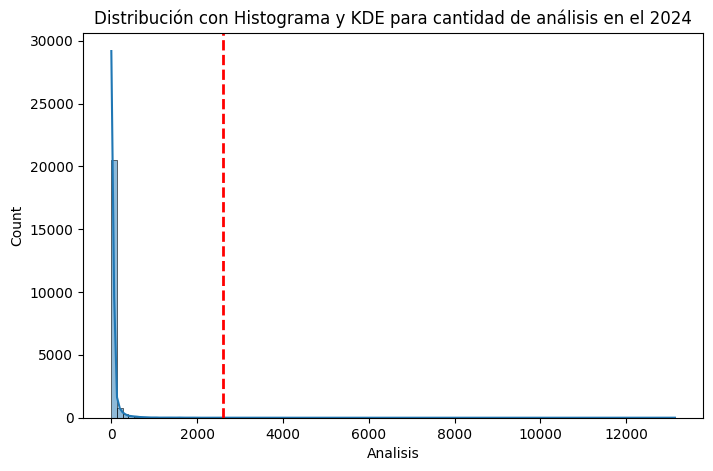

In [37]:
p75 = df['Analisis'].quantile(0.999)



plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x='Analisis',
    kde=True,  # Opcional: añade la curva de densidad (KDE) suavizada
    bins=100    # Define el número de barras
)
# 2. Agregamos la línea vertical
plt.axvline(
    x=p75,           # La posición en el eje X (el valor del percentil)
    color='red',     # Color de la línea (rojo para que resalte)
    linestyle='--',  # Estilo de línea (punteada)
    linewidth=2,     # Grosor
    label=f'Percentil 75: {p75:.2f}' # Etiqueta para la leyenda
)

plt.title('Distribución con Histograma y KDE para cantidad de análisis en el 2024')
plt.show()

In [38]:
def filtrar_por_percentil_superior(df, columna, p=0.999):

    # 1. Calcular el límite exacto (el valor del percentil indicado, ej: 80)
    limite_superior = df[columna].quantile(p)

    # Opcional: Imprimir para saber cuál es el corte
    print(f"Límite superior (P{int(p*100)}) para '{columna}': {limite_superior:.2f}")

    # 2. Crear la máscara (True si el valor es MENOR o IGUAL al límite)
    # Esto elimina todo lo que sea mayor al percentil 80.
    mascara_no_outlier = (df[columna] <= limite_superior)

    return mascara_no_outlier

# Columnas a limpiar
columna_1 = 'Analisis'
#columna_2 = 'Distancia'

# 1. Obtener la máscara usando el percentil 0.80 (80%)
mascara_1 = filtrar_por_percentil_superior(df, columna_1, p=0.999)

# 2. Obtener la máscara para la segunda columna
#mascara_2 = filtrar_por_percentil_superior(df, columna_2, p=0.999)

# 3. Combinar las máscaras: solo mantenemos filas que cumplan AMBOS criterios
mascara_final = mascara_1 #& mascara_2

# 4. Aplicar el filtro al DataFrame original
df_limpio = df[mascara_final]

# Verificación rápida
print(f"Filas originales: {len(df)}")
print(f"Filas limpias: {len(df_limpio)}")

Límite superior (P99) para 'Analisis': 2602.46
Filas originales: 21943
Filas limpias: 21921


In [39]:
df= df_limpio.copy()

# EDA

In [40]:
#f['Pacientes nuevos 2024'] = df['Pacientes nuevos 2024'].fillna(0)
df['Categoria'] = df['Categoria'].fillna('Otros')
df['Categoria'].unique()

array(['Clínicas privadas (Red de Seguros)', 'Consultorio Particular',
       'Clínicas privadas (No red de Seguros)', 'Otros',
       'Hospitales MINSA', 'Hospitales ESSALUD', 'Hospitales de Policía',
       'Centros de Salud Municipales', 'Postas del MINSA',
       'Hospitales FAP', 'Hospitales Navales', 'Hospitales Militares',
       'CAFAE'], dtype=object)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21921 entries, 0 to 21942
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_medico                 21921 non-null  int64  
 1   Recuento de id_ingreso    21921 non-null  int64  
 2   Analisis                  21921 non-null  int64  
 3   id_sexo                   21877 non-null  object 
 4   Edad_medico               21921 non-null  float64
 5   Colegio                   21917 non-null  object 
 6   Especialidad              21921 non-null  object 
 7   Antiguedad                21921 non-null  int64  
 8   Categoria                 21921 non-null  object 
 9   Arquetipo                 9546 non-null   object 
 10  Distancia                 18636 non-null  float64
 11  c2017                     21921 non-null  int64  
 12  c2018                     21921 non-null  int64  
 13  c2019                     21921 non-null  int64  
 14  c2020      

In [42]:
df_corr = df.select_dtypes(include='number')
df_corr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21921 entries, 0 to 21942
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_medico                 21921 non-null  int64  
 1   Recuento de id_ingreso    21921 non-null  int64  
 2   Analisis                  21921 non-null  int64  
 3   Edad_medico               21921 non-null  float64
 4   Antiguedad                21921 non-null  int64  
 5   Distancia                 18636 non-null  float64
 6   c2017                     21921 non-null  int64  
 7   c2018                     21921 non-null  int64  
 8   c2019                     21921 non-null  int64  
 9   c2020                     21921 non-null  int64  
 10  c2021                     21921 non-null  int64  
 11  c2022                     21921 non-null  int64  
 12  c2023                     21921 non-null  int64  
 13  c2024                     21921 non-null  int64  
 14  c2025      

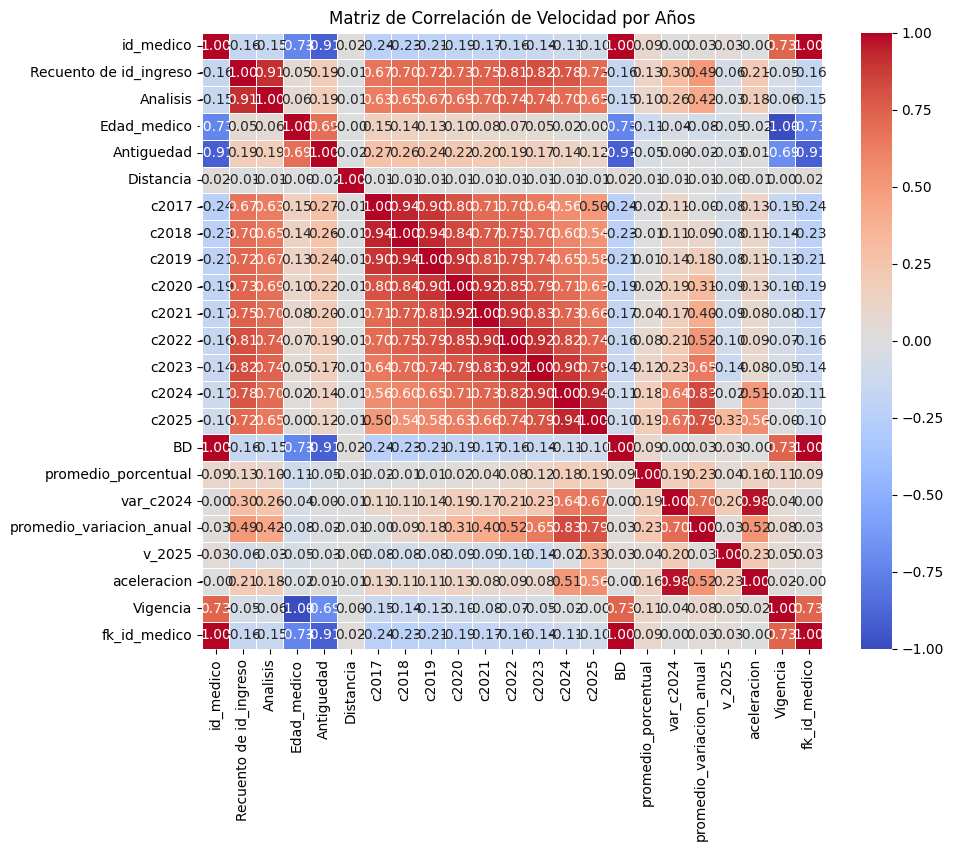

In [43]:
# --- CÁLCULO DE CORRELACIÓN ---
# Calcula la matriz de correlación
matriz_correlacion = df_corr.corr()

# --- GRÁFICO ---
plt.figure(figsize=(10, 8)) # Ajusta el tamaño del gráfico

sns.heatmap(matriz_correlacion,
            annot=True,        # Muestra los números dentro de los cuadros
            cmap='coolwarm',   # Esquema de color: Rojo (positivo) - Azul (negativo)
            fmt=".2f",         # Formato a 2 decimales
            linewidths=0.5)    # Líneas blancas entre cuadros

plt.title("Matriz de Correlación de Velocidad por Años")
plt.show()



# df_p

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21921 entries, 0 to 21942
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_medico                 21921 non-null  int64  
 1   Recuento de id_ingreso    21921 non-null  int64  
 2   Analisis                  21921 non-null  int64  
 3   id_sexo                   21877 non-null  object 
 4   Edad_medico               21921 non-null  float64
 5   Colegio                   21917 non-null  object 
 6   Especialidad              21921 non-null  object 
 7   Antiguedad                21921 non-null  int64  
 8   Categoria                 21921 non-null  object 
 9   Arquetipo                 9546 non-null   object 
 10  Distancia                 18636 non-null  float64
 11  c2017                     21921 non-null  int64  
 12  c2018                     21921 non-null  int64  
 13  c2019                     21921 non-null  int64  
 14  c2020      

In [45]:
df_p = df.copy()#.drop('id_medico',axis=1)
#df_p = df[['Analisis','Pacientes nuevos 2024','id_sexo','Edad_medico','Colegio','Especialidad','Antiguedad','Distancia','Categoria','var_c2024','promedio_variacion_anual','aceleracion','v_2025']]
#df_p = df_p.drop(['Fecha 1º atencion medico','Fecha Uº atencion medico'],axis=1)
#df_p['Pacientes nuevos 2024'] = df_p['Pacientes nuevos 2024'].fillna(0)
df_p['Analisis'] = df_p['Analisis'].fillna(0)
df_p=df_p[df_p['Colegio']=='CMP Colegio Médico del Perú']
df_p['Categoria'] = df_p['Categoria'].fillna('Otros')
df_p=df_p[df_p['Colegio']=='CMP Colegio Médico del Perú']
df_p = df_p.drop('Colegio',axis=1)
#df_p = df_p[['id_medico','Edad_medico','Especialidad','Categoria','id_sexo','Antiguedad','Distancia','NSE_Mas_Comun','promedio_variacion_anual','c2017','c2018','c2019','c2020','c2021','c2022','c2023','c2024','c2025']]
df_p = df_p[['id_medico','Edad_medico','Especialidad','Categoria','id_sexo','Antiguedad','Distancia','NSE_Mas_Comun','promedio_porcentual','promedio_variacion_anual','c2025']]
mediana_prod = df_p['Distancia'].median()
df_p['Distancia'].fillna(mediana_prod, inplace=True)
df_p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21349 entries, 0 to 21942
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_medico                 21349 non-null  int64  
 1   Edad_medico               21349 non-null  float64
 2   Especialidad              21349 non-null  object 
 3   Categoria                 21349 non-null  object 
 4   id_sexo                   21342 non-null  object 
 5   Antiguedad                21349 non-null  int64  
 6   Distancia                 21349 non-null  float64
 7   NSE_Mas_Comun             21348 non-null  object 
 8   promedio_porcentual       21349 non-null  float64
 9   promedio_variacion_anual  21349 non-null  float64
 10  c2025                     21349 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 2.0+ MB


/tmp/ipykernel_2046/1018447143.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_p['Distancia'].fillna(mediana_prod, inplace=True)


In [46]:
df_p = df_p.dropna()
df_p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21341 entries, 0 to 21942
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_medico                 21341 non-null  int64  
 1   Edad_medico               21341 non-null  float64
 2   Especialidad              21341 non-null  object 
 3   Categoria                 21341 non-null  object 
 4   id_sexo                   21341 non-null  object 
 5   Antiguedad                21341 non-null  int64  
 6   Distancia                 21341 non-null  float64
 7   NSE_Mas_Comun             21341 non-null  object 
 8   promedio_porcentual       21341 non-null  float64
 9   promedio_variacion_anual  21341 non-null  float64
 10  c2025                     21341 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 2.0+ MB


In [47]:
cols_numericas = df_p.select_dtypes(include=['int64', 'float64']).columns
cols_numericas

Index(['id_medico', 'Edad_medico', 'Antiguedad', 'Distancia',
       'promedio_porcentual', 'promedio_variacion_anual', 'c2025'],
      dtype='object')

In [48]:
cols_categoricas = df_p.select_dtypes(include=['object', 'category']).columns

for col in cols_categoricas:
    if col in df_p.columns:
        # Esto convierte el número 15 en el texto "15" y elimina el conflicto
        df_p[col] = df_p[col].astype(str)

        # Limpieza extra: Quitar espacios vacíos que a veces molestan
        df_p[col] = df_p[col].str.strip()

In [49]:
cols_categoricas

Index(['Especialidad', 'Categoria', 'id_sexo', 'NSE_Mas_Comun'], dtype='object')

In [50]:
df_p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21341 entries, 0 to 21942
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_medico                 21341 non-null  int64  
 1   Edad_medico               21341 non-null  float64
 2   Especialidad              21341 non-null  object 
 3   Categoria                 21341 non-null  object 
 4   id_sexo                   21341 non-null  object 
 5   Antiguedad                21341 non-null  int64  
 6   Distancia                 21341 non-null  float64
 7   NSE_Mas_Comun             21341 non-null  object 
 8   promedio_porcentual       21341 non-null  float64
 9   promedio_variacion_anual  21341 non-null  float64
 10  c2025                     21341 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 2.0+ MB


In [51]:
#cols_anos = ['c2017', 'c2018', 'c2019', 'c2020']

# 3. Calculamos la diferencia (Año actual - Año anterior)
# axis=1 indica que la operación es horizontal (entre columnas)
#df_variacion = df_p[cols_anos].diff(axis=1)

# Eliminamos la columna c2017 porque da NaN (no hay año 2016 para restar)
#df_variacion = df_variacion.drop(columns=['c2017'])

# (Opcional) Renombramos las columnas para que se entienda que es variación
# Esto cambiará los nombres a 'var_c2018', 'var_c2019', etc.
#df_variacion.columns = ['var_' + col for col in df_variacion.columns]

# 4. Calculamos el PROMEDIO de esas variaciones numéricas
#df_p['prom_last_3_year'] = df_variacion.mean(axis=1)

## 5. Unimos todo para ver el resultado final
#resultado_final = pd.concat([df_p[['id_medico']], df_variacion, df_variacion[['prom_last_3_year']]], axis=1)

#print(resultado_final)

In [52]:
#df_p =  pd.merge(
#    df_p,                    # DataFrame de la izquierda (el principal)
#    resultado_final[['id_medico','prom_last_3_year']],               # DataFrame de la derecha (el que tiene la info extra)
#    left_on='id_medico',         # Columna del DF de la izquierda a usar para la unión
#    right_on='id_medico',            # Indica que el DF de la derecha debe usar su INDEX para la unión
#    how='left'                   # Tipo de unión (left mantiene todas las filas de df_datos)
#)

## df_p_1

In [53]:
df_p_1 = df_p.copy()
#df_p_1 = df_p_1.drop(['c2021','c2022','c2023','c2024'],axis=1)
df_p_1

,id_medico,Edad_medico,Especialidad,Categoria,id_sexo,Antiguedad,Distancia,NSE_Mas_Comun,promedio_porcentual,promedio_variacion_anual,c2025
0,3,84.0,GINECOLOGIA Y OBSTETRICIA,Clínicas privadas (Red de Seguros),M,33,5.897048,AB,3.292906,1.142857,112.363636
1,10,85.0,PEDIATRIA,Consultorio Particular,F,33,0.922944,AB,-24.400195,-20.285714,1.090909
2,18,57.0,NEFROLOGIA,Clínicas privadas (Red de Seguros),M,33,1.905874,CD,42.995636,7.714286,48.000000
3,20,76.0,GINECOLOGIA Y OBSTETRICIA,Clínicas privadas (Red de Seguros),M,33,0.948698,AB,-4.125496,-11.000000,98.181818
4,21,70.0,MEDICINA INTERNA,Clínicas privadas (Red de Seguros),M,33,0.408610,AB,4.757015,7.428571,249.818182
...,...,...,...,...,...,...,...,...,...,...,...
21938,55261,61.0,TRAUMATOLOGIA Y ORTEPEDIA,Hospitales MINSA,M,1,0.360428,BC,0.000000,0.142857,2.181818
21939,55274,46.0,ANESTESIOLOGIA,Hospitales ESSALUD,M,0,0.545209,AB,0.000000,0.142857,1.090909
21940,55423,41.0,CIRUGIA GENERAL,Hospitales MINSA,M,1,2.494491,PROV,0.000000,0.142857,7.636364
21941,55425,39.0,ENFERMEDADES INFECCIOSAS Y TROPICALES,Clínicas privadas (No red de Seguros),F,1,1.245265,PROV,0.000000,0.142857,5.454545


In [54]:
# Cambiar nombre de columnas
df_p_1 = df_p_1.rename(columns={
    'c2017': 'año_1',
    'c2018': 'año_2',
    'c2019': 'año_3',
    'c2020': 'año_4'
})

In [55]:
#df_p_1['last_var']=df_p_1['año_4']-df_p_1['año_3']
#df_p_1

In [56]:
df_p_1['Vigencia'] = 80 - df_p_1['Edad_medico']

# IMPORTANTE: Corregir los que ya pasaron de 80 años.
# No queremos números negativos (ej. -5), queremos que se queden en 0.
df_p_1['Vigencia'] = df_p_1['Vigencia'].clip(lower=0)

In [57]:
#df_p_1['v_target'] = df_p_1['c2025'] - df_p_1['año_4']

#bins = [-float('inf'), 0, float('inf')]

#labels = [0, 1]  # 0=Caída Fuerte, ..., 4=Subida Fuerte

#df_p_1['target'] = pd.cut(df_p_1['v_target'], bins=bins, labels=labels)


In [58]:
df_p_1

,id_medico,Edad_medico,Especialidad,Categoria,id_sexo,Antiguedad,Distancia,NSE_Mas_Comun,promedio_porcentual,promedio_variacion_anual,c2025,Vigencia
0,3,84.0,GINECOLOGIA Y OBSTETRICIA,Clínicas privadas (Red de Seguros),M,33,5.897048,AB,3.292906,1.142857,112.363636,0.0
1,10,85.0,PEDIATRIA,Consultorio Particular,F,33,0.922944,AB,-24.400195,-20.285714,1.090909,0.0
2,18,57.0,NEFROLOGIA,Clínicas privadas (Red de Seguros),M,33,1.905874,CD,42.995636,7.714286,48.000000,23.0
3,20,76.0,GINECOLOGIA Y OBSTETRICIA,Clínicas privadas (Red de Seguros),M,33,0.948698,AB,-4.125496,-11.000000,98.181818,4.0
4,21,70.0,MEDICINA INTERNA,Clínicas privadas (Red de Seguros),M,33,0.408610,AB,4.757015,7.428571,249.818182,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...
21938,55261,61.0,TRAUMATOLOGIA Y ORTEPEDIA,Hospitales MINSA,M,1,0.360428,BC,0.000000,0.142857,2.181818,19.0
21939,55274,46.0,ANESTESIOLOGIA,Hospitales ESSALUD,M,0,0.545209,AB,0.000000,0.142857,1.090909,34.0
21940,55423,41.0,CIRUGIA GENERAL,Hospitales MINSA,M,1,2.494491,PROV,0.000000,0.142857,7.636364,39.0
21941,55425,39.0,ENFERMEDADES INFECCIOSAS Y TROPICALES,Clínicas privadas (No red de Seguros),F,1,1.245265,PROV,0.000000,0.142857,5.454545,41.0


In [59]:
df_flask = df_p_1.copy()

# Modelo

In [60]:
# CON O SIN VELOCIDAD
df_p_1 = df_flask
#df_p_1 = df_p_1[['id_medico','Edad_medico','Especialidad','Categoria','id_sexo','Antiguedad','Distancia','NSE_Mas_Comun','Vigencia','c2025']]
df_p_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21341 entries, 0 to 21942
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_medico                 21341 non-null  int64  
 1   Edad_medico               21341 non-null  float64
 2   Especialidad              21341 non-null  object 
 3   Categoria                 21341 non-null  object 
 4   id_sexo                   21341 non-null  object 
 5   Antiguedad                21341 non-null  int64  
 6   Distancia                 21341 non-null  float64
 7   NSE_Mas_Comun             21341 non-null  object 
 8   promedio_porcentual       21341 non-null  float64
 9   promedio_variacion_anual  21341 non-null  float64
 10  c2025                     21341 non-null  float64
 11  Vigencia                  21341 non-null  float64
dtypes: float64(6), int64(2), object(4)
memory usage: 2.1+ MB


# Modelo Predictivo de Potencial

In [61]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [62]:
df_p_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21341 entries, 0 to 21942
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_medico                 21341 non-null  int64  
 1   Edad_medico               21341 non-null  float64
 2   Especialidad              21341 non-null  object 
 3   Categoria                 21341 non-null  object 
 4   id_sexo                   21341 non-null  object 
 5   Antiguedad                21341 non-null  int64  
 6   Distancia                 21341 non-null  float64
 7   NSE_Mas_Comun             21341 non-null  object 
 8   promedio_porcentual       21341 non-null  float64
 9   promedio_variacion_anual  21341 non-null  float64
 10  c2025                     21341 non-null  float64
 11  Vigencia                  21341 non-null  float64
dtypes: float64(6), int64(2), object(4)
memory usage: 2.1+ MB


In [63]:
#numero_corte = 15
corte_down = 4
corte_up = 30

#Umbral superior
umbral_up = 20

#umbral inferior dinámico
# m = (20-50)/(30-4)
# df_p_1['umbral_down'] = m * df_p_1['c2025'] - m*4 + 50
# df_p_1['umbral_down'] = df_p_1['umbral_down'].clip(lower=20, upper=50)


#umbral_decision = 0.2 # Para binary logistic : solo dos variables
# Umbral de decisión:
# - Si ponemos 0.5: Es el estándar.
# - Si ponemos 0.7: Eres "Exigente". Sube la Precisión, baja el Recall (Menos falsos positivos).
# - Si ponemos 0.3: Eres "Permisivo". Sube el Recall, baja la Precisión (Capturas más potenciales, pero más errores).

In [64]:
import numpy as np
import pandas as pd

# Asegúrate de usar el nombre correcto de tu columna de porcentaje
col_variacion = 'promedio_porcentual'

# 1. LISTA DE CONDICIONES (Prioridad de arriba hacia abajo)
condiciones = [
    # PRIORIDAD 1: CLASE 2 (Grandes Consagrados)
    # Tienen buen volumen (>30) y buen crecimiento (>50%)
    (df_p_1['c2025'] > corte_up) & (df_p_1[col_variacion] > umbral_up),
    # (df_p_1['c2025'] > corte_up) & (df_p_1[col_variacion] > 30),

    # PRIORIDAD 2: CLASE 1 (Pequeños Explosivos)
    # Tienen poco volumen (>4) pero crecimiento brutal (>200%)
    # (df_p_1['c2025'] >= corte_down) & (df_p_1[col_variacion] > df_p_1['umbral_down'])
    (df_p_1['c2025'] > corte_down) & (df_p_1[col_variacion] > 50)
]

# 2. LISTA DE RESULTADOS (En el mismo orden que las condiciones)
elecciones = [2, 1]

# 3. APLICAR LÓGICA (Aquí definimos el 0)
df_p_1['target_multiclase'] = np.select(
    condiciones,
    elecciones,
    default=0  # <--- AQUÍ ESTÁ: Si no es 2 ni 1, es 0.
)

# --- VERIFICACIÓN ---
print("Distribución del Target:")
print(df_p_1['target_multiclase'].value_counts().sort_index())

print("\n--- Chequeo de lógica 'Caso 0' ---")
# Mostramos algunos casos que quedaron en 0 para validar
# Deberían tener volumen bajo O crecimiento pobre
cols_ver = ['c2025', col_variacion, 'target_multiclase']
print(df_p_1[df_p_1['target_multiclase'] == 0][cols_ver].head(5))

Distribución del Target:
target_multiclase
0    17173
1     2874
2     1294
Name: count, dtype: int64

--- Chequeo de lógica 'Caso 0' ---
        c2025  promedio_porcentual  target_multiclase
0  112.363636             3.292906                  0
1    1.090909           -24.400195                  0
3   98.181818            -4.125496                  0
4  249.818182             4.757015                  0
6    7.636364            18.055556                  0


In [65]:
df_p_1.drop('c2025',axis=1)

,id_medico,Edad_medico,Especialidad,Categoria,id_sexo,Antiguedad,Distancia,NSE_Mas_Comun,promedio_porcentual,promedio_variacion_anual,Vigencia,target_multiclase
0,3,84.0,GINECOLOGIA Y OBSTETRICIA,Clínicas privadas (Red de Seguros),M,33,5.897048,AB,3.292906,1.142857,0.0,0
1,10,85.0,PEDIATRIA,Consultorio Particular,F,33,0.922944,AB,-24.400195,-20.285714,0.0,0
2,18,57.0,NEFROLOGIA,Clínicas privadas (Red de Seguros),M,33,1.905874,CD,42.995636,7.714286,23.0,2
3,20,76.0,GINECOLOGIA Y OBSTETRICIA,Clínicas privadas (Red de Seguros),M,33,0.948698,AB,-4.125496,-11.000000,4.0,0
4,21,70.0,MEDICINA INTERNA,Clínicas privadas (Red de Seguros),M,33,0.408610,AB,4.757015,7.428571,10.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
21938,55261,61.0,TRAUMATOLOGIA Y ORTEPEDIA,Hospitales MINSA,M,1,0.360428,BC,0.000000,0.142857,19.0,0
21939,55274,46.0,ANESTESIOLOGIA,Hospitales ESSALUD,M,0,0.545209,AB,0.000000,0.142857,34.0,0
21940,55423,41.0,CIRUGIA GENERAL,Hospitales MINSA,M,1,2.494491,PROV,0.000000,0.142857,39.0,0
21941,55425,39.0,ENFERMEDADES INFECCIOSAS Y TROPICALES,Clínicas privadas (No red de Seguros),F,1,1.245265,PROV,0.000000,0.142857,41.0,0


In [66]:
df_p_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21341 entries, 0 to 21942
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_medico                 21341 non-null  int64  
 1   Edad_medico               21341 non-null  float64
 2   Especialidad              21341 non-null  object 
 3   Categoria                 21341 non-null  object 
 4   id_sexo                   21341 non-null  object 
 5   Antiguedad                21341 non-null  int64  
 6   Distancia                 21341 non-null  float64
 7   NSE_Mas_Comun             21341 non-null  object 
 8   promedio_porcentual       21341 non-null  float64
 9   promedio_variacion_anual  21341 non-null  float64
 10  c2025                     21341 non-null  float64
 11  Vigencia                  21341 non-null  float64
 12  target_multiclase         21341 non-null  int64  
dtypes: float64(6), int64(3), object(4)
memory usage: 2.3+ MB


In [67]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score

# 1. LIMPIEZA INICIAL
# Eliminamos columnas de target anteriores si existen para evitar confusiones
for col in ['target_binario','target']:
    if col in df_p_1.columns:
        df_p_1 = df_p_1.drop(col, axis=1)

# Variables a borrar de X (incluyendo la variable c2025 que es la respuesta)
cols_drop = ['id_medico', 'c2025','umbral_down','target_multiclase']

# 2. DEFINIR X (Predictoras)
# Hacemos esto ANTES de crear el target para asegurar que el target no entre en X
X_original = df_p_1.drop([c for c in cols_drop if c in df_p_1.columns], axis=1)

# Aseguramos categorías
cols_texto = ['id_sexo', 'Especialidad', 'Categoria', 'NSE_Mas_Comun']
for col in cols_texto:
    if col in X_original.columns:
        X_original[col] = X_original[col].astype("category")

print("Preparando target y modelo multiclase...")

# 3. CREAR TARGET DE 3 CLASES
# # Cortes: Hasta 12 | Entre 12 y 16 | Más de 16
# # Bins: [-inf, 12, 16, inf]
# bins_final = [-float('inf'), corte_1, corte_2, float('inf')]
# labels_final = [0, 1, 2] # 0: Bajo, 1: Medio, 2: Alto

# df_p_1['target_multiclase'] = pd.cut(df_p_1['c2025'], bins=bins_final, labels=labels_final).astype(int)

# Verificamos cuántos hay de cada uno
print("Distribución de Clases:")
print(df_p_1['target_multiclase'].value_counts().sort_index())
print("Ref: 0=(<4), 1=(4-30), 2=(>20)")

y_final = df_p_1['target_multiclase']
X_train, X_test, y_train, y_test = train_test_split(X_original, y_final, test_size=0.2, random_state=42)

from sklearn.utils.class_weight import compute_sample_weight

# --- ESTRATEGIA 1: CALCULAR PESOS ---
# Esto le dice al modelo: "Equivocarte en la clase pequeña es 10 veces más grave
# que equivocarte en la clase grande".
weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# 4. CONFIGURAR MODELO MULTICLASE
# model_final = XGBClassifier(
#     enable_categorical=True,
#     tree_method='hist',
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=5,
#     objective='multi:softprob',
#     num_class=3
# )
model_final = XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    objective='multi:softprob',
    num_class=3,

    # A. Aumentamos la capacidad de aprendizaje
    n_estimators=200,         # Un poco más de árboles
    learning_rate=0.05,       # Más lento para aprender detalles finos

    # B. Permitimos que el modelo sea más específico (menos generalista)
    max_depth=6,              # Un poco más profundo para capturar casos difíciles
    min_child_weight=1,       # Permite hojas con pocos datos (crucial para Recall)

    # C. Parámetro MÁGICO para desbalance
    max_delta_step=1,         # Ayuda a converger cuando una clase es muy dominante

    n_jobs=-1,
    random_state=42
)

model_final.fit(X_train, y_train, sample_weight=weights)

# 5. PREDICCIÓN
# En multiclase, predict() devuelve directamente la clase con mayor probabilidad (0, 1 o 2)
# Ya no usamos un umbral manual simple como en binario
y_pred_final = model_final.predict(X_test)

# 6. REPORTES
print("\n--- REPORTES FINALES ---")
print("Accuracy Final:", accuracy_score(y_test, y_pred_final))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_final))

# Matriz de confusión para ver dónde se equivoca entre las 3 opciones
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_final))

print("\nReporte Detallado:")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=['Clase 0 (<=4)', 'Clase 1 (4-30)', 'Clase 2 (>20)']
))

Preparando target y modelo multiclase...
Distribución de Clases:
target_multiclase
0    17173
1     2874
2     1294
Name: count, dtype: int64
Ref: 0=(<4), 1=(4-30), 2=(>20)

--- REPORTES FINALES ---
Accuracy Final: 0.8751464043101429
Balanced Accuracy: 0.8585888421580278

Matriz de Confusión:
[[2980  361   69]
 [   7  533   25]
 [  19   52  223]]

Reporte Detallado:
                precision    recall  f1-score   support

 Clase 0 (<=4)       0.99      0.87      0.93      3410
Clase 1 (4-30)       0.56      0.94      0.71       565
 Clase 2 (>20)       0.70      0.76      0.73       294

      accuracy                           0.88      4269
     macro avg       0.75      0.86      0.79      4269
  weighted avg       0.91      0.88      0.89      4269



## Métrica y matriz de confusión

In [68]:
print("\n--- Resultados del XGBClassifier ---")
print(f"Accuracy (Exactitud): {accuracy_score(y_test, y_pred_final):.4f}")

print("\nReporte de Clasificación:")
# target_names es opcional, solo para que se lea bonito
#print(classification_report(y_test, y_pred, target_names=['Bajó', 'Estable', 'Subió']))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_final))

print("Accuracy Final validado:", accuracy_score(y_test, y_pred_final))

# 1. Reporte completo (Muestra Precision, Recall y F1 para cada clase)
print("--- Métricas del modelo ---")
print(classification_report(y_test, y_pred_final)) #, target_names=['Bajó', 'Estable', 'Subió']))

# 2. Balanced Accuracy
b_acc = balanced_accuracy_score(y_test, y_pred_final)
print(f"Balanced Accuracy: {b_acc:.4f}")

# 3. F1 Macro (Promedio de los F1 sin importar el tamaño de la clase)
f1_mac = f1_score(y_test, y_pred_final, average='macro')
print(f"F1-Score Macro: {f1_mac:.4f}")



--- Resultados del XGBClassifier ---
Accuracy (Exactitud): 0.8751

Reporte de Clasificación:

Matriz de Confusión:
[[2980  361   69]
 [   7  533   25]
 [  19   52  223]]
Accuracy Final validado: 0.8751464043101429
--- Métricas del modelo ---
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      3410
           1       0.56      0.94      0.71       565
           2       0.70      0.76      0.73       294

    accuracy                           0.88      4269
   macro avg       0.75      0.86      0.79      4269
weighted avg       0.91      0.88      0.89      4269

Balanced Accuracy: 0.8586
F1-Score Macro: 0.7881


In [69]:
df_p_1[df_p_1['c2025']>30].count(), df_p_1.count()

(id_medico                   1963
 Edad_medico                 1963
 Especialidad                1963
 Categoria                   1963
 id_sexo                     1963
 Antiguedad                  1963
 Distancia                   1963
 NSE_Mas_Comun               1963
 promedio_porcentual         1963
 promedio_variacion_anual    1963
 c2025                       1963
 Vigencia                    1963
 target_multiclase           1963
 dtype: int64,
 id_medico                   21341
 Edad_medico                 21341
 Especialidad                21341
 Categoria                   21341
 id_sexo                     21341
 Antiguedad                  21341
 Distancia                   21341
 NSE_Mas_Comun               21341
 promedio_porcentual         21341
 promedio_variacion_anual    21341
 c2025                       21341
 Vigencia                    21341
 target_multiclase           21341
 dtype: int64)

# Modelo Predictivo Nuevos

In [70]:
df_nuevos = df_p_1
df_nuevos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21341 entries, 0 to 21942
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_medico                 21341 non-null  int64  
 1   Edad_medico               21341 non-null  float64
 2   Especialidad              21341 non-null  object 
 3   Categoria                 21341 non-null  object 
 4   id_sexo                   21341 non-null  object 
 5   Antiguedad                21341 non-null  int64  
 6   Distancia                 21341 non-null  float64
 7   NSE_Mas_Comun             21341 non-null  object 
 8   promedio_porcentual       21341 non-null  float64
 9   promedio_variacion_anual  21341 non-null  float64
 10  c2025                     21341 non-null  float64
 11  Vigencia                  21341 non-null  float64
 12  target_multiclase         21341 non-null  int64  
dtypes: float64(6), int64(3), object(4)
memory usage: 2.3+ MB


In [71]:
df_nuevos = df_nuevos.drop(['id_medico','id_sexo','Antiguedad','Distancia','NSE_Mas_Comun','promedio_porcentual','promedio_variacion_anual','c2025','Vigencia'],axis=1)
df_nuevos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21341 entries, 0 to 21942
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Edad_medico        21341 non-null  float64
 1   Especialidad       21341 non-null  object 
 2   Categoria          21341 non-null  object 
 3   target_multiclase  21341 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 833.6+ KB


,Edad_medico,Especialidad,Categoria
0,84.0,GINECOLOGIA Y OBSTETRICIA,Clínicas privadas (Red de Seguros)
1,85.0,PEDIATRIA,Consultorio Particular
2,57.0,NEFROLOGIA,Clínicas privadas (Red de Seguros)
3,76.0,GINECOLOGIA Y OBSTETRICIA,Clínicas privadas (Red de Seguros)
4,70.0,MEDICINA INTERNA,Clínicas privadas (Red de Seguros)
...,...,...,...
21938,61.0,TRAUMATOLOGIA Y ORTEPEDIA,Hospitales MINSA
21939,46.0,ANESTESIOLOGIA,Hospitales ESSALUD
21940,41.0,CIRUGIA GENERAL,Hospitales MINSA
21941,39.0,ENFERMEDADES INFECCIOSAS Y TROPICALES,Clínicas privadas (No red de Seguros)


In [72]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score


# Variables a borrar de X (incluyendo la variable c2025 que es la respuesta)
cols_drop = ['target_multiclase']

# 2. DEFINIR X (Predictoras)
# Hacemos esto ANTES de crear el target para asegurar que el target no entre en X
X_original = df_nuevos.drop([c for c in cols_drop if c in df_p_1.columns], axis=1)

# Aseguramos categorías
cols_texto = ['Especialidad','Categoria']
for col in cols_texto:
    if col in X_original.columns:
        X_original[col] = X_original[col].astype("category")

print("Preparando target y modelo multiclase...")


y_final = df_nuevos['target_multiclase']
X_train, X_test, y_train, y_test = train_test_split(X_original, y_final, test_size=0.2, random_state=42)

from sklearn.utils.class_weight import compute_sample_weight

# --- ESTRATEGIA 1: CALCULAR PESOS ---
# Esto le dice al modelo: "Equivocarte en la clase pequeña es 10 veces más grave
# que equivocarte en la clase grande".
weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# 4. CONFIGURAR MODELO MULTICLASE
# model_final = XGBClassifier(
#     enable_categorical=True,
#     tree_method='hist',
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=5,
#     objective='multi:softprob',
#     num_class=3
# )
model_final = XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    objective='multi:softprob',
    num_class=3,

    # A. Aumentamos la capacidad de aprendizaje
    n_estimators=5000,         # Un poco más de árboles
    learning_rate=0.05,       # Más lento para aprender detalles finos

    # B. Permitimos que el modelo sea más específico (menos generalista)
    max_depth=6,              # Un poco más profundo para capturar casos difíciles
    min_child_weight=1,       # Permite hojas con pocos datos (crucial para Recall)

    # C. Parámetro MÁGICO para desbalance
    max_delta_step=1,         # Ayuda a converger cuando una clase es muy dominante

    n_jobs=-1,
    random_state=42
)

model_final.fit(X_train, y_train, sample_weight=weights)

# 5. PREDICCIÓN
# En multiclase, predict() devuelve directamente la clase con mayor probabilidad (0, 1 o 2)
# Ya no usamos un umbral manual simple como en binario
y_pred_final = model_final.predict(X_test)

# 6. REPORTES
print("\n--- REPORTES FINALES ---")
print("Accuracy Final:", accuracy_score(y_test, y_pred_final))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_final))

# Matriz de confusión para ver dónde se equivoca entre las 3 opciones
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_final))

print("\nReporte Detallado:")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=['Clase 0 (<=4)', 'Clase 1 (4-30)', 'Clase 2 (>20)']
))

Preparando target y modelo multiclase...

--- REPORTES FINALES ---
Accuracy Final: 0.5113609744670883
Balanced Accuracy: 0.3930830204554767

Matriz de Confusión:
[[1924  977  509]
 [ 278  163  124]
 [ 111   87   96]]

Reporte Detallado:
                precision    recall  f1-score   support

 Clase 0 (<=4)       0.83      0.56      0.67      3410
Clase 1 (4-30)       0.13      0.29      0.18       565
 Clase 2 (>20)       0.13      0.33      0.19       294

      accuracy                           0.51      4269
     macro avg       0.37      0.39      0.35      4269
  weighted avg       0.69      0.51      0.57      4269



In [77]:
import json
import numpy as np

# 1. Guardar el modelo XGBoost en un archivo temporal
# XGBoost usa su propia estructura interna para representar los árboles
model_final.save_model("temp_xgb.json")

# 2. Leer la estructura para integrarla al JSON final
with open("temp_xgb.json", "r") as f:
    xgb_structure = json.load(f)

# 3. Crear el diccionario unificado sin parámetros de escalado
model_export = {
    "model_type": "XGBClassifier",
    "xgb_model_data": xgb_structure,
    "classes": model_final.classes_.tolist(),
    "n_features": model_final.n_features_in_  # Útil para validar el input en el HTML
}

# 4. Guardar en el archivo final
with open('modelo_completo_xgb.json', 'w', encoding='utf-8') as f:
    json.dump(model_export, f, indent=4, ensure_ascii=False)

print("✅ Modelo XGBoost (sin escalado) exportado con éxito.")

✅ Modelo XGBoost (sin escalado) exportado con éxito.


# FIN

Con datos escalados

In [76]:
# import json
# import numpy as np

# # 1. Guardar el modelo XGBoost en un archivo temporal o buffer
# # XGBoost tiene su propio método optimizado para JSON
# model_final.save_model("temp_xgb.json")

# # 2. Cargar esa estructura para integrarla en nuestro export final
# with open("temp_xgb.json", "r") as f:
#     xgb_structure = json.load(f)

# # 3. Crear el diccionario unificado
# model_export = {
#     "model_type": "XGBClassifier",
#     "scaler_params": {
#         "means": scaler.mean_.tolist(),
#         "std": scaler.scale_.tolist()
#     },
#     "xgb_model_data": xgb_structure,
#     "classes": model_final.classes_.tolist() # Para saber qué significa 0, 1, 2...
# }

# # 4. Guardar todo en un único archivo JSON
# with open('modelo_completo_xgb.json', 'w', encoding='utf-8') as f:
#     json.dump(model_export, f, indent=4, ensure_ascii=False)

# print("✅ Modelo XGBoost y Scaler exportados con éxito.")

IndentationError: unexpected indent (2353760484.py, line 19)

In [73]:
a

NameError: name 'a' is not defined

## Peso de variables

In [ ]:
# Obtener diccionario de importancia tipo 'gain'
importance_gain = model_final.get_booster().get_score(importance_type='gain')

# Convertir a listas para graficar o ver
keys = list(importance_gain.keys())
values = list(importance_gain.values())

df_gain = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by="score", ascending=False)
print(df_gain)

## Estadísticas de predicciones

In [ ]:
df_gain.head(8).index.tolist()

# Predicción

In [ ]:
df_p_1.info()

In [ ]:
cols_problema = ['Especialidad', 'Categoria', 'id_sexo', 'NSE_Mas_Comun']
for col in cols_problema:
    df_p_1[col] = df_p_1[col].astype('category')

columnas_modelo = X_test.columns
X_full = df_p_1[columnas_modelo]


#Realizar la predicción
# Usamos X_full (o X_full_scaled si aplica)
df_p_1['Prediccion_Produccion'] = model_final.predict(X_full)
# 4. Ver los primeros resultados
print(df_p_1[['id_medico', 'target_multiclase', 'Prediccion_Produccion']].head())

In [ ]:
top_5_todas = df_gain.head(8).index.tolist()

# 2. Identificamos qué columnas son numéricas en tu df original
cols_numericas = df_p_1.select_dtypes(include='number').columns

top_features = [col for col in top_5_todas if col in cols_numericas]

# 2. Agrupamos el DataFrame original por el target y sacamos la media
# Asumiendo que 'target_cat' es tu columna objetivo y df tiene los datos originales
#analisis_promedio = df_p_1.groupby('target_multiclase')[top_features].mean()
analisis_promedio = df_p_1.groupby('Prediccion_Produccion')[top_features].mean()

print("--- Promedio de las variables top por cada clase ---")
print(analisis_promedio)

# También es útil ver la mediana por si hay outliers
print("\n--- Mediana (menos sensible a outliers) ---")
print(df_p_1.groupby('target_multiclase')[top_features].median())

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el tamaño del gráfico
plt.figure(figsize=(15, 5 * len(top_features)))

for i, var in enumerate(top_features):
    plt.subplot(len(top_features), 1, i + 1)

    # Boxplot: Muestra la mediana y los cuartiles
    sns.boxplot(x='Prediccion_Produccion', y=var, data=df_p_1, palette="viridis")

    plt.title(f'Comportamiento de {var} según el Target')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import shap
# 1. Cargar el explicador (usa el modelo ya entrenado)
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test)
print("Tipo de shap_values:", type(shap_values))

if isinstance(shap_values, list):
    print("Es una lista (Multiclase). Longitud:", len(shap_values))
    print("Forma de la clase 2:", shap_values[2].shape)
else:
    print("Forma de shap_values:", shap_values.shape)

print("Forma de X_test:", X_test.shape)

## Grupo Muy Potencial

In [ ]:
import shap

# 1. Cargar el explicador (usa el modelo ya entrenado)
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test)

# 2. Graficar
# Para clasificación multiclase, shap_values es una lista de arrays (uno por clase).
# Clase 0 = Bajó, Clase 1 = Estable, Clase 2 = Subió

# Ejemplo para ver qué empuja a la Clase 2 (Subió)
print("Impacto de variables para la Clase 2 (Muy potencial):")
shap.summary_plot(shap_values[:,:,2], X_test)

In [ ]:
import shap

# 1. Cargar el explicador (usa el modelo ya entrenado)
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test)

# 2. Graficar
# Para clasificación multiclase, shap_values es una lista de arrays (uno por clase).
# Clase 0 = Bajó, Clase 1 = Estable, Clase 2 = Subió

# Ejemplo para ver qué empuja a la Clase 2 (Subió)
print("Impacto de variables para la Clase 1 (Potencial):")
shap.summary_plot(shap_values[:,:,1], X_test)

In [ ]:
import shap

# 1. Cargar el explicador (usa el modelo ya entrenado)
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test)

# 2. Graficar
# Para clasificación multiclase, shap_values es una lista de arrays (uno por clase).
# Clase 0 = Bajó, Clase 1 = Estable, Clase 2 = Subió

# Ejemplo para ver qué empuja a la Clase 2 (Subió)
print("Impacto de variables para la Clase 0 (No potencial):")
shap.summary_plot(shap_values[:,:,0], X_test)

## SHAP Especialidad

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

variable = 'Especialidad'
clase_interes = 2  # Clase Alto Potencial (>30)

# 1. EXTRACCIÓN DE SHAP VALUES (Igual que antes)
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    shap_v_target = shap_values[:, :, clase_interes]

col_idx = X_test.columns.get_loc(variable)

df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 2. FILTRADO: SOLO IMPACTOS POSITIVOS
# ---------------------------------------------------------

# A. Calculamos el promedio REAL (con signo positivo o negativo) por categoría
promedios = df_grafico.groupby('Categoria')['Impacto_SHAP'].mean()

# B. Filtramos solo las que tienen promedio > 0 (Positivas)
# Si quisieras ser más estricto, podrías poner > 0.1, etc.
solo_positivas = promedios[promedios > 0]

# C. Ordenamos de mayor a menor impacto y tomamos el Top 10
# (Opcional: Si quieres ver TODAS las positivas, quita el .head(10))
top_positivos = solo_positivas.sort_values(ascending=False).head(10).index

# D. Filtramos el DataFrame original para graficar solo esas
df_plot = df_grafico[df_grafico['Categoria'].isin(top_positivos)]

# Verificación de seguridad (por si ninguna es positiva)
if len(top_positivos) == 0:
    print("¡Ojo! No hay ninguna especialidad con impacto promedio positivo para esta clase.")
else:
    # ---------------------------------------------------------
    # 3. GRAFICAR
    # ---------------------------------------------------------
    plt.figure(figsize=(10, len(top_positivos) * 0.8))

    # Boxplot
    sns.boxplot(
        data=df_plot,
        y='Categoria',
        x='Impacto_SHAP',
        order=top_positivos, # Usamos el orden de los positivos
        palette="Greens",    # Usamos tonos verdes para indicar "Positivo/Bueno"
        showfliers=False,
        linewidth=0.5
    )

    # Puntos (Stripplot)
    sns.stripplot(
        data=df_plot,
        y='Categoria',
        x='Impacto_SHAP',
        order=top_positivos,
        size=2,
        color='black',
        alpha=0.3
    )

    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)

    # Línea roja en 0
    plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)

    plt.title(f"Top Especialidades que AUMENTAN la probabilidad de ser Alto Potencial", fontsize=14)
    plt.xlabel("Impacto SHAP Promedio (>0)", fontsize=12)
    plt.show()

In [ ]:
variable = 'Especialidad'
clase_interes = 2  # <--- INDICE DE LA CLASE QUE QUIERES VER (2 = Alto / >16)

# EXTRACCIÓN CRÍTICA:
# En modelos multiclase, shap_values suele ser una lista: [Array_Clase0, Array_Clase1, Array_Clase2]
# Necesitamos seleccionar solo los valores de la clase 2.
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    # En algunas versiones es un array 3D: (filas, columnas, clases)
    shap_v_target = shap_values[:, :, clase_interes]

# Buscamos el índice de la columna variable
col_idx = X_test.columns.get_loc(variable)

# Creamos el DataFrame temporal usando SOLO los valores de la clase 2
df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 3. FILTRADO Y ORDENAMIENTO (TOP 10)
# ---------------------------------------------------------
# Recomendado: Filtrar solo las Top 10 para que el gráfico sea legible
# Ordenamos por magnitud absoluta del impacto (importancia real)
top_categorias = df_grafico.assign(abs_impact=df_grafico['Impacto_SHAP'].abs())\
                           .groupby('Categoria')['abs_impact'].mean()\
                           .sort_values(ascending=False).index[:10]

# Filtramos el DF original para dejar solo esas 10
df_plot = df_grafico[df_grafico['Categoria'].isin(top_categorias)]

# ---------------------------------------------------------
# 4. GRAFICAR
# ---------------------------------------------------------
plt.figure(figsize=(10, len(top_categorias) * 0.8))

# Boxplot
sns.boxplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    palette="viridis",
    showfliers=False,
    linewidth=0.5
)

# Puntos (Stripplot)
sns.stripplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    size=2,
    color='black',
    alpha=0.3
)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.title(f"Impacto de {variable} en la Probabilidad de ser Clase {clase_interes} (>30)")
plt.xlabel("Impacto SHAP (Derecha = Aumenta prob. de ser Alto | Izquierda = Disminuye)")
plt.show()

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

variable = 'Especialidad'
clase_interes = 1  # Clase Alto Potencial (>30)

# 1. EXTRACCIÓN DE SHAP VALUES (Igual que antes)
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    shap_v_target = shap_values[:, :, clase_interes]

col_idx = X_test.columns.get_loc(variable)

df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 2. FILTRADO: SOLO IMPACTOS POSITIVOS
# ---------------------------------------------------------

# A. Calculamos el promedio REAL (con signo positivo o negativo) por categoría
promedios = df_grafico.groupby('Categoria')['Impacto_SHAP'].mean()

# B. Filtramos solo las que tienen promedio > 0 (Positivas)
# Si quisieras ser más estricto, podrías poner > 0.1, etc.
solo_positivas = promedios[promedios > 0]

# C. Ordenamos de mayor a menor impacto y tomamos el Top 10
# (Opcional: Si quieres ver TODAS las positivas, quita el .head(10))
top_positivos = solo_positivas.sort_values(ascending=False).head(10).index

# D. Filtramos el DataFrame original para graficar solo esas
df_plot = df_grafico[df_grafico['Categoria'].isin(top_positivos)]

# Verificación de seguridad (por si ninguna es positiva)
if len(top_positivos) == 0:
    print("¡Ojo! No hay ninguna especialidad con impacto promedio positivo para esta clase.")
else:
    # ---------------------------------------------------------
    # 3. GRAFICAR
    # ---------------------------------------------------------
    plt.figure(figsize=(10, len(top_positivos) * 0.8))

    # Boxplot
    sns.boxplot(
        data=df_plot,
        y='Categoria',
        x='Impacto_SHAP',
        order=top_positivos, # Usamos el orden de los positivos
        palette="Greens",    # Usamos tonos verdes para indicar "Positivo/Bueno"
        showfliers=False,
        linewidth=0.5
    )

    # Puntos (Stripplot)
    sns.stripplot(
        data=df_plot,
        y='Categoria',
        x='Impacto_SHAP',
        order=top_positivos,
        size=2,
        color='black',
        alpha=0.3
    )

    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)

    # Línea roja en 0
    plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)

    plt.title(f"Top Especialidades que AUMENTAN la probabilidad de ser Potencial", fontsize=14)
    plt.xlabel("Impacto SHAP Promedio (>0)", fontsize=12)
    plt.show()

In [ ]:
variable = 'Especialidad'
clase_interes = 1  # <--- INDICE DE LA CLASE QUE QUIERES VER (2 = Alto / >16)

# EXTRACCIÓN CRÍTICA:
# En modelos multiclase, shap_values suele ser una lista: [Array_Clase0, Array_Clase1, Array_Clase2]
# Necesitamos seleccionar solo los valores de la clase 2.
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    # En algunas versiones es un array 3D: (filas, columnas, clases)
    shap_v_target = shap_values[:, :, clase_interes]

# Buscamos el índice de la columna variable
col_idx = X_test.columns.get_loc(variable)

# Creamos el DataFrame temporal usando SOLO los valores de la clase 2
df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 3. FILTRADO Y ORDENAMIENTO (TOP 10)
# ---------------------------------------------------------
# Recomendado: Filtrar solo las Top 10 para que el gráfico sea legible
# Ordenamos por magnitud absoluta del impacto (importancia real)
top_categorias = df_grafico.assign(abs_impact=df_grafico['Impacto_SHAP'].abs())\
                           .groupby('Categoria')['abs_impact'].mean()\
                           .sort_values(ascending=False).index[:10]

# Filtramos el DF original para dejar solo esas 10
df_plot = df_grafico[df_grafico['Categoria'].isin(top_categorias)]

# ---------------------------------------------------------
# 4. GRAFICAR
# ---------------------------------------------------------
plt.figure(figsize=(10, len(top_categorias) * 0.8))

# Boxplot
sns.boxplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    palette="viridis",
    showfliers=False,
    linewidth=0.5
)

# Puntos (Stripplot)
sns.stripplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    size=2,
    color='black',
    alpha=0.3
)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.title(f"Impacto de {variable} en la Probabilidad de ser Clase {clase_interes} (>4 y <30)")
plt.xlabel("Impacto SHAP (Derecha = Aumenta prob. de ser Alto | Izquierda = Disminuye)")
plt.show()


In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

variable = 'Especialidad'
clase_interes = 0  # Clase Alto Potencial (>30)

# 1. EXTRACCIÓN DE SHAP VALUES (Igual que antes)
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    shap_v_target = shap_values[:, :, clase_interes]

col_idx = X_test.columns.get_loc(variable)

df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 2. FILTRADO: SOLO IMPACTOS POSITIVOS
# ---------------------------------------------------------

# A. Calculamos el promedio REAL (con signo positivo o negativo) por categoría
promedios = df_grafico.groupby('Categoria')['Impacto_SHAP'].mean()

# B. Filtramos solo las que tienen promedio > 0 (Positivas)
# Si quisieras ser más estricto, podrías poner > 0.1, etc.
solo_positivas = promedios[promedios > 0]

# C. Ordenamos de mayor a menor impacto y tomamos el Top 10
# (Opcional: Si quieres ver TODAS las positivas, quita el .head(10))
top_positivos = solo_positivas.sort_values(ascending=False).head(10).index

# D. Filtramos el DataFrame original para graficar solo esas
df_plot = df_grafico[df_grafico['Categoria'].isin(top_positivos)]

# Verificación de seguridad (por si ninguna es positiva)
if len(top_positivos) == 0:
    print("¡Ojo! No hay ninguna especialidad con impacto promedio positivo para esta clase.")
else:
    # ---------------------------------------------------------
    # 3. GRAFICAR
    # ---------------------------------------------------------
    plt.figure(figsize=(10, len(top_positivos) * 0.8))

    # Boxplot
    sns.boxplot(
        data=df_plot,
        y='Categoria',
        x='Impacto_SHAP',
        order=top_positivos, # Usamos el orden de los positivos
        palette="Greens",    # Usamos tonos verdes para indicar "Positivo/Bueno"
        showfliers=False,
        linewidth=0.5
    )

    # Puntos (Stripplot)
    sns.stripplot(
        data=df_plot,
        y='Categoria',
        x='Impacto_SHAP',
        order=top_positivos,
        size=2,
        color='black',
        alpha=0.3
    )

    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)

    # Línea roja en 0
    plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)

    plt.title(f"Top Especialidades que AUMENTAN la probabilidad de ser No Potencial", fontsize=14)
    plt.xlabel("Impacto SHAP Promedio (>0)", fontsize=12)
    plt.show()

In [ ]:
variable = 'Especialidad'
clase_interes = 0  # <--- INDICE DE LA CLASE QUE QUIERES VER (2 = Alto / >16)

# EXTRACCIÓN CRÍTICA:
# En modelos multiclase, shap_values suele ser una lista: [Array_Clase0, Array_Clase1, Array_Clase2]
# Necesitamos seleccionar solo los valores de la clase 2.
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    # En algunas versiones es un array 3D: (filas, columnas, clases)
    shap_v_target = shap_values[:, :, clase_interes]

# Buscamos el índice de la columna variable
col_idx = X_test.columns.get_loc(variable)

# Creamos el DataFrame temporal usando SOLO los valores de la clase 2
df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 3. FILTRADO Y ORDENAMIENTO (TOP 10)
# ---------------------------------------------------------
# Recomendado: Filtrar solo las Top 10 para que el gráfico sea legible
# Ordenamos por magnitud absoluta del impacto (importancia real)
top_categorias = df_grafico.assign(abs_impact=df_grafico['Impacto_SHAP'].abs())\
                           .groupby('Categoria')['abs_impact'].mean()\
                           .sort_values(ascending=False).index[:10]

# Filtramos el DF original para dejar solo esas 10
df_plot = df_grafico[df_grafico['Categoria'].isin(top_categorias)]

# ---------------------------------------------------------
# 4. GRAFICAR
# ---------------------------------------------------------
plt.figure(figsize=(10, len(top_categorias) * 0.8))

# Boxplot
sns.boxplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    palette="viridis",
    showfliers=False,
    linewidth=0.5
)

# Puntos (Stripplot)
sns.stripplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    size=2,
    color='black',
    alpha=0.3
)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.title(f"Impacto de {variable} en la Probabilidad de ser Clase {clase_interes} (<4)")
plt.xlabel("Impacto SHAP (Derecha = Aumenta prob. de ser No Potencial | Izquierda = Disminuye)")
plt.show()

## SHAP Categoría

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

variable = 'Categoria'
clase_interes = 2  # Clase Alto Potencial (>30)

# 1. EXTRACCIÓN DE SHAP VALUES (Igual que antes)
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    shap_v_target = shap_values[:, :, clase_interes]

col_idx = X_test.columns.get_loc(variable)

df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 2. FILTRADO: SOLO IMPACTOS POSITIVOS
# ---------------------------------------------------------

# A. Calculamos el promedio REAL (con signo positivo o negativo) por categoría
promedios = df_grafico.groupby('Categoria')['Impacto_SHAP'].mean()

# B. Filtramos solo las que tienen promedio > 0 (Positivas)
# Si quisieras ser más estricto, podrías poner > 0.1, etc.
solo_positivas = promedios[promedios > 0]

# C. Ordenamos de mayor a menor impacto y tomamos el Top 10
# (Opcional: Si quieres ver TODAS las positivas, quita el .head(10))
top_positivos = solo_positivas.sort_values(ascending=False).head(10).index

# D. Filtramos el DataFrame original para graficar solo esas
df_plot = df_grafico[df_grafico['Categoria'].isin(top_positivos)]

# Verificación de seguridad (por si ninguna es positiva)
if len(top_positivos) == 0:
    print("¡Ojo! No hay ninguna especialidad con impacto promedio positivo para esta clase.")
else:
    # ---------------------------------------------------------
    # 3. GRAFICAR
    # ---------------------------------------------------------
    plt.figure(figsize=(10, len(top_positivos) * 0.8))

    # Boxplot
    sns.boxplot(
        data=df_plot,
        y='Categoria',
        x='Impacto_SHAP',
        order=top_positivos, # Usamos el orden de los positivos
        palette="Greens",    # Usamos tonos verdes para indicar "Positivo/Bueno"
        showfliers=False,
        linewidth=0.5
    )

    # Puntos (Stripplot)
    sns.stripplot(
        data=df_plot,
        y='Categoria',
        x='Impacto_SHAP',
        order=top_positivos,
        size=2,
        color='black',
        alpha=0.3
    )

    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)

    # Línea roja en 0
    plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)

    plt.title(f"Top Especialidades que AUMENTAN la probabilidad de ser Alto Potencial", fontsize=14)
    plt.xlabel("Impacto SHAP Promedio (>0)", fontsize=12)
    plt.show()

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

variable = 'Categoria'
clase_interes = 1  # Clase Alto Potencial (>30)

# 1. EXTRACCIÓN DE SHAP VALUES (Igual que antes)
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    shap_v_target = shap_values[:, :, clase_interes]

col_idx = X_test.columns.get_loc(variable)

df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 2. FILTRADO: SOLO IMPACTOS POSITIVOS
# ---------------------------------------------------------

# A. Calculamos el promedio REAL (con signo positivo o negativo) por categoría
promedios = df_grafico.groupby('Categoria')['Impacto_SHAP'].mean()

# B. Filtramos solo las que tienen promedio > 0 (Positivas)
# Si quisieras ser más estricto, podrías poner > 0.1, etc.
solo_positivas = promedios[promedios > 0]

# C. Ordenamos de mayor a menor impacto y tomamos el Top 10
# (Opcional: Si quieres ver TODAS las positivas, quita el .head(10))
top_positivos = solo_positivas.sort_values(ascending=False).head(10).index

# D. Filtramos el DataFrame original para graficar solo esas
df_plot = df_grafico[df_grafico['Categoria'].isin(top_positivos)]

# Verificación de seguridad (por si ninguna es positiva)
if len(top_positivos) == 0:
    print("¡Ojo! No hay ninguna especialidad con impacto promedio positivo para esta clase.")
else:
    # ---------------------------------------------------------
    # 3. GRAFICAR
    # ---------------------------------------------------------
    plt.figure(figsize=(10, len(top_positivos) * 0.8))

    # Boxplot
    sns.boxplot(
        data=df_plot,
        y='Categoria',
        x='Impacto_SHAP',
        order=top_positivos, # Usamos el orden de los positivos
        palette="Greens",    # Usamos tonos verdes para indicar "Positivo/Bueno"
        showfliers=False,
        linewidth=0.5
    )

    # Puntos (Stripplot)
    sns.stripplot(
        data=df_plot,
        y='Categoria',
        x='Impacto_SHAP',
        order=top_positivos,
        size=2,
        color='black',
        alpha=0.3
    )

    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)

    # Línea roja en 0
    plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)

    plt.title(f"Top Especialidades que AUMENTAN la probabilidad de ser Potencial", fontsize=14)
    plt.xlabel("Impacto SHAP Promedio (>0)", fontsize=12)
    plt.show()

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

variable = 'Categoria'
clase_interes = 0  # Clase Alto Potencial (>30)

# 1. EXTRACCIÓN DE SHAP VALUES (Igual que antes)
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    shap_v_target = shap_values[:, :, clase_interes]

col_idx = X_test.columns.get_loc(variable)

df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 2. FILTRADO: SOLO IMPACTOS POSITIVOS
# ---------------------------------------------------------

# A. Calculamos el promedio REAL (con signo positivo o negativo) por categoría
promedios = df_grafico.groupby('Categoria')['Impacto_SHAP'].mean()

# B. Filtramos solo las que tienen promedio > 0 (Positivas)
# Si quisieras ser más estricto, podrías poner > 0.1, etc.
solo_positivas = promedios[promedios > 0]

# C. Ordenamos de mayor a menor impacto y tomamos el Top 10
# (Opcional: Si quieres ver TODAS las positivas, quita el .head(10))
top_positivos = solo_positivas.sort_values(ascending=False).head(10).index

# D. Filtramos el DataFrame original para graficar solo esas
df_plot = df_grafico[df_grafico['Categoria'].isin(top_positivos)]

# Verificación de seguridad (por si ninguna es positiva)
if len(top_positivos) == 0:
    print("¡Ojo! No hay ninguna especialidad con impacto promedio positivo para esta clase.")
else:
    # ---------------------------------------------------------
    # 3. GRAFICAR
    # ---------------------------------------------------------
    plt.figure(figsize=(10, len(top_positivos) * 0.8))

    # Boxplot
    sns.boxplot(
        data=df_plot,
        y='Categoria',
        x='Impacto_SHAP',
        order=top_positivos, # Usamos el orden de los positivos
        palette="Greens",    # Usamos tonos verdes para indicar "Positivo/Bueno"
        showfliers=False,
        linewidth=0.5
    )

    # Puntos (Stripplot)
    sns.stripplot(
        data=df_plot,
        y='Categoria',
        x='Impacto_SHAP',
        order=top_positivos,
        size=2,
        color='black',
        alpha=0.3
    )

    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)

    # Línea roja en 0
    plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)

    plt.title(f"Top Especialidades que AUMENTAN la probabilidad de ser No Potencial", fontsize=14)
    plt.xlabel("Impacto SHAP Promedio (>0)", fontsize=12)
    plt.show()

In [ ]:
variable = 'Categoria'
clase_interes = 1  # <--- INDICE DE LA CLASE QUE QUIERES VER (2 = Alto / >16)

# EXTRACCIÓN CRÍTICA:
# En modelos multiclase, shap_values suele ser una lista: [Array_Clase0, Array_Clase1, Array_Clase2]
# Necesitamos seleccionar solo los valores de la clase 2.
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    # En algunas versiones es un array 3D: (filas, columnas, clases)
    shap_v_target = shap_values[:, :, clase_interes]

# Buscamos el índice de la columna variable
col_idx = X_test.columns.get_loc(variable)

# Creamos el DataFrame temporal usando SOLO los valores de la clase 2
df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 3. FILTRADO Y ORDENAMIENTO (TOP 10)
# ---------------------------------------------------------
# Recomendado: Filtrar solo las Top 10 para que el gráfico sea legible
# Ordenamos por magnitud absoluta del impacto (importancia real)
top_categorias = df_grafico.assign(abs_impact=df_grafico['Impacto_SHAP'].abs())\
                           .groupby('Categoria')['abs_impact'].mean()\
                           .sort_values(ascending=False).index[:10]

# Filtramos el DF original para dejar solo esas 10
df_plot = df_grafico[df_grafico['Categoria'].isin(top_categorias)]

# ---------------------------------------------------------
# 4. GRAFICAR
# ---------------------------------------------------------
plt.figure(figsize=(10, len(top_categorias) * 0.6))

# Boxplot
sns.boxplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    palette="viridis",
    showfliers=False,
    linewidth=0.5
)

# Puntos (Stripplot)
sns.stripplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    size=2,
    color='black',
    alpha=0.3
)

plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.title(f"Impacto de {variable} en la Probabilidad de ser Clase {clase_interes} (>4 y <30)")
plt.xlabel("Impacto SHAP (Derecha = Aumenta prob. de ser Potencial | Izquierda = Disminuye)")
plt.show()

In [ ]:
variable = 'Categoria'
clase_interes = 0  # <--- INDICE DE LA CLASE QUE QUIERES VER (2 = Alto / >16)

# EXTRACCIÓN CRÍTICA:
# En modelos multiclase, shap_values suele ser una lista: [Array_Clase0, Array_Clase1, Array_Clase2]
# Necesitamos seleccionar solo los valores de la clase 2.
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    # En algunas versiones es un array 3D: (filas, columnas, clases)
    shap_v_target = shap_values[:, :, clase_interes]

# Buscamos el índice de la columna variable
col_idx = X_test.columns.get_loc(variable)

# Creamos el DataFrame temporal usando SOLO los valores de la clase 2
df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 3. FILTRADO Y ORDENAMIENTO (TOP 10)
# ---------------------------------------------------------
# Recomendado: Filtrar solo las Top 10 para que el gráfico sea legible
# Ordenamos por magnitud absoluta del impacto (importancia real)
top_categorias = df_grafico.assign(abs_impact=df_grafico['Impacto_SHAP'].abs())\
                           .groupby('Categoria')['abs_impact'].mean()\
                           .sort_values(ascending=False).index[:10]

# Filtramos el DF original para dejar solo esas 10
df_plot = df_grafico[df_grafico['Categoria'].isin(top_categorias)]

# ---------------------------------------------------------
# 4. GRAFICAR
# ---------------------------------------------------------
plt.figure(figsize=(10, len(top_categorias) * 0.6))

# Boxplot
sns.boxplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    palette="viridis",
    showfliers=False,
    linewidth=0.5
)

# Puntos (Stripplot)
sns.stripplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    size=2,
    color='black',
    alpha=0.3
)

plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.title(f"Impacto de {variable} en la Probabilidad de ser Clase {clase_interes} (<4)")
plt.xlabel("Impacto SHAP (Derecha = Aumenta prob. de ser No Potencial | Izquierda = Disminuye)")
plt.show()

## SHAP NSE

In [ ]:
variable = 'NSE_Mas_Comun'
clase_interes = 2  # <--- INDICE DE LA CLASE QUE QUIERES VER (2 = Alto / >16)

# EXTRACCIÓN CRÍTICA:
# En modelos multiclase, shap_values suele ser una lista: [Array_Clase0, Array_Clase1, Array_Clase2]
# Necesitamos seleccionar solo los valores de la clase 2.
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    # En algunas versiones es un array 3D: (filas, columnas, clases)
    shap_v_target = shap_values[:, :, clase_interes]

# Buscamos el índice de la columna variable
col_idx = X_test.columns.get_loc(variable)

# Creamos el DataFrame temporal usando SOLO los valores de la clase 2
df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 3. FILTRADO Y ORDENAMIENTO (TOP 10)
# ---------------------------------------------------------
# Recomendado: Filtrar solo las Top 10 para que el gráfico sea legible
# Ordenamos por magnitud absoluta del impacto (importancia real)
top_categorias = df_grafico.assign(abs_impact=df_grafico['Impacto_SHAP'].abs())\
                           .groupby('Categoria')['abs_impact'].mean()\
                           .sort_values(ascending=False).index[:10]

# Filtramos el DF original para dejar solo esas 10
df_plot = df_grafico[df_grafico['Categoria'].isin(top_categorias)]

# ---------------------------------------------------------
# 4. GRAFICAR
# ---------------------------------------------------------
plt.figure(figsize=(10, len(top_categorias) * 0.6))

# Boxplot
sns.boxplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    palette="viridis",
    showfliers=False,
    linewidth=0.5
)

# Puntos (Stripplot)
sns.stripplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    size=2,
    color='black',
    alpha=0.3
)

plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.title(f"Impacto de {variable} en la Probabilidad de ser Clase {clase_interes} (>30)")
plt.xlabel("Impacto SHAP (Derecha = Aumenta prob. de ser Muy Potencial | Izquierda = Disminuye)")
plt.show()

In [ ]:
variable = 'NSE_Mas_Comun'
clase_interes = 1  # <--- INDICE DE LA CLASE QUE QUIERES VER (2 = Alto / >16)

# EXTRACCIÓN CRÍTICA:
# En modelos multiclase, shap_values suele ser una lista: [Array_Clase0, Array_Clase1, Array_Clase2]
# Necesitamos seleccionar solo los valores de la clase 2.
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    # En algunas versiones es un array 3D: (filas, columnas, clases)
    shap_v_target = shap_values[:, :, clase_interes]

# Buscamos el índice de la columna variable
col_idx = X_test.columns.get_loc(variable)

# Creamos el DataFrame temporal usando SOLO los valores de la clase 2
df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 3. FILTRADO Y ORDENAMIENTO (TOP 10)
# ---------------------------------------------------------
# Recomendado: Filtrar solo las Top 10 para que el gráfico sea legible
# Ordenamos por magnitud absoluta del impacto (importancia real)
top_categorias = df_grafico.assign(abs_impact=df_grafico['Impacto_SHAP'].abs())\
                           .groupby('Categoria')['abs_impact'].mean()\
                           .sort_values(ascending=False).index[:10]

# Filtramos el DF original para dejar solo esas 10
df_plot = df_grafico[df_grafico['Categoria'].isin(top_categorias)]

# ---------------------------------------------------------
# 4. GRAFICAR
# ---------------------------------------------------------
plt.figure(figsize=(10, len(top_categorias) * 0.6))

# Boxplot
sns.boxplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    palette="viridis",
    showfliers=False,
    linewidth=0.5
)

# Puntos (Stripplot)
sns.stripplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    size=2,
    color='black',
    alpha=0.3
)

plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.title(f"Impacto de {variable} en la Probabilidad de ser Clase {clase_interes} (>4 y <30)")
plt.xlabel("Impacto SHAP (Derecha = Aumenta prob. de ser Potencial | Izquierda = Disminuye)")
plt.show()

In [ ]:
variable = 'NSE_Mas_Comun'
clase_interes = 0  # <--- INDICE DE LA CLASE QUE QUIERES VER (2 = Alto / >16)

# EXTRACCIÓN CRÍTICA:
# En modelos multiclase, shap_values suele ser una lista: [Array_Clase0, Array_Clase1, Array_Clase2]
# Necesitamos seleccionar solo los valores de la clase 2.
if isinstance(shap_values, list):
    shap_v_target = shap_values[clase_interes]
else:
    # En algunas versiones es un array 3D: (filas, columnas, clases)
    shap_v_target = shap_values[:, :, clase_interes]

# Buscamos el índice de la columna variable
col_idx = X_test.columns.get_loc(variable)

# Creamos el DataFrame temporal usando SOLO los valores de la clase 2
df_grafico = pd.DataFrame({
    'Categoria': X_test[variable].values,
    'Impacto_SHAP': shap_v_target[:, col_idx]
})

# ---------------------------------------------------------
# 3. FILTRADO Y ORDENAMIENTO (TOP 10)
# ---------------------------------------------------------
# Recomendado: Filtrar solo las Top 10 para que el gráfico sea legible
# Ordenamos por magnitud absoluta del impacto (importancia real)
top_categorias = df_grafico.assign(abs_impact=df_grafico['Impacto_SHAP'].abs())\
                           .groupby('Categoria')['abs_impact'].mean()\
                           .sort_values(ascending=False).index[:10]

# Filtramos el DF original para dejar solo esas 10
df_plot = df_grafico[df_grafico['Categoria'].isin(top_categorias)]

# ---------------------------------------------------------
# 4. GRAFICAR
# ---------------------------------------------------------
plt.figure(figsize=(10, len(top_categorias) * 0.6))

# Boxplot
sns.boxplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    palette="viridis",
    showfliers=False,
    linewidth=0.5
)

# Puntos (Stripplot)
sns.stripplot(
    data=df_plot,
    y='Categoria',
    x='Impacto_SHAP',
    order=top_categorias,
    size=2,
    color='black',
    alpha=0.3
)

plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.title(f"Impacto de {variable} en la Probabilidad de ser Clase {clase_interes} (<4)")
plt.xlabel("Impacto SHAP (Derecha = Aumenta prob. de ser No Potencial | Izquierda = Disminuye)")
plt.show()

# Exportando modelo

In [ ]:
df_arboles = model_final.get_booster().trees_to_dataframe()

# Explicación de columnas clave:
# 'Feature': La variable sobre la que se toma la decisión.
# 'Split': El valor de corte (ej: si Edad < 30).
# 'Gain': La importancia de esa decisión para el modelo.
# 'Tree': El número de árbol (del 0 al 149).

# 2. Exportar a Excel
df_arboles.to_excel("reglas_modelo_xgb.xlsx", index=False)

print("Estructura de árboles exportada correctamente.")

In [ ]:
df_arboles

In [ ]:
df_p_1.to_excel("datos_modelo_predictivo.xlsx", index=False)

In [ ]:

a

In [ ]:
df_p_1['Especialidad'].unique()

In [ ]:
df_p_1.info()

In [ ]:
cruce_por_especialidad = pd.crosstab(df_p_1['Especialidad'], df_p_1['Prediccion_Produccion'], normalize='index') * 100

# Graficamos de nuevo
plt.figure(figsize=(12, 8))
sns.heatmap(cruce_por_especialidad,
            annot=True,
            fmt=".1f",
            cmap="YlGnBu",
            cbar_kws={'label': '% de la Especialidad'})

plt.title("Distribución de cada Especialidad en la Predicción (Suma 100% por fila)")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos la distribución Global (% real de cada especialidad en toda la base)
global_probs = df_p_1['Especialidad'].value_counts(normalize=True)

# 2. Calculamos la distribución por Cluster (Crosstab normalizado por columnas)
# Esto nos dice: "Dentro del Arquetipo X, qué % representa cada especialidad"
cluster_probs = pd.crosstab(df_p_1['Especialidad'], df_p_1['Prediccion_Produccion'], normalize='columns')

# 3. Calculamos la Matriz de Lift
# Dividimos la probabilidad local (cluster) entre la global
# axis=0 asegura que la división se alinee por el índice (las especialidades)
lift_matrix = cluster_probs.div(global_probs, axis=0)

# (Opcional) Llenamos NaNs con 0 si alguna especialidad no existe en algún cluster
lift_matrix = lift_matrix.fillna(0)

# 4. GRAFICAR MATRIZ (HEATMAP)
plt.figure(figsize=(12, 10)) # Ajusta el alto según la cantidad de especialidades

sns.heatmap(
    lift_matrix,
    annot=True,           # Muestra los valores numéricos
    fmt=".2f",            # 2 decimales
    cmap="RdBu_r",        # Mapa Divergente: Rojo=Alto Lift, Azul=Bajo Lift
    center=1.0,           # El centro es 1 (el promedio global)
    linewidths=.5,
    cbar_kws={'label': 'Lift (Afinidad)'}
)

plt.title('Matriz de Lift: Afinidad de Especialidades por Potencialidad')
plt.xlabel('Potencialidad')
plt.ylabel('Especialidad')
plt.show()

# Encontrando los mejores rangos para tener el mayor accuracy

## Balanced Accuracy

### Probs totales

Variando corte y umbral

In [ ]:
#df_p_1[df_p_1['c2025']<=0]
np.percentile(df_p_1['c2025'],60),np.percentile(df_p_1['c2025'],70),np.percentile(df_p_1['c2025'],80),np.percentile(df_p_1['c2025'],92)

In [ ]:
a

In [ ]:
import numpy as np
import pandas as pd
import itertools
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

# --- 1. PREPARACIÓN DE DATOS ---

# Limpieza inicial
if 'Prediccion_Produccion' in df_p_1.columns: df_p_1 = df_p_1.drop('Prediccion_Produccion', axis=1)

# Variables a excluir
cols_drop = ['id_medico', 'c2025']

# Definimos X base
X_original = df_p_1.drop([c for c in cols_drop if c in df_p_1.columns], axis=1)

# Aseguramos categorías
cols_texto = ['id_sexo', 'Especialidad', 'Categoria', 'NSE_Mas_Comun']
for col in cols_texto:
    if col in X_original.columns:
        X_original[col] = X_original[col].astype("category")

# Valores para iterar
variacion = df_p_1['c2025'].values

# --- 2. DEFINICIÓN DE CANDIDATOS PARA LOS CORTES ---

# Definimos rangos de búsqueda basados en percentiles
candidatos_low = np.unique(np.percentile(variacion, np.arange(60, 80, 1)))
candidatos_high = np.unique(np.percentile(variacion, np.arange(70, 92, 1)))

best_b_acc = 0
best_cuts = (0, 0) # (low, high)

# Calculamos cuántas combinaciones probaremos
combinaciones = [ (l, h) for l in candidatos_low for h in candidatos_high if l < h ]
print(f"Iniciando búsqueda de optimización en {len(combinaciones)} escenarios de cortes...")

# --- 3. BUCLE DE OPTIMIZACIÓN ---

for cut_low, cut_high in combinaciones:

    # El corte bajo debe ser menor al alto
    if cut_low >= cut_high:
        continue

    # A. Crear target temporal de 3 clases
    bins = [-float('inf'), cut_low, cut_high, float('inf')]
    y_temp = pd.cut(variacion, bins=bins, labels=[0, 1, 2]).astype(int)

    # B. Validación: Evitar clases minúsculas
    # --- CORRECCIÓN AQUÍ ---
    # Convertimos el array de numpy a pd.Series para poder usar value_counts()
    counts = pd.Series(y_temp).value_counts(normalize=True)

    if counts.min() < 0.05:
        continue # Saltamos esta combinación

    # C. Split
    X_train, X_test, y_train, y_test = train_test_split(X_original, y_temp, test_size=0.2, random_state=42)

    # D. Entrenar Modelo Rápido
    model = XGBClassifier(
        enable_categorical=True,
        tree_method='hist',
        n_estimators=50,
        learning_rate=0.1,
        max_depth=4,
        objective='multi:softprob',
        num_class=3,
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)

    # E. Predecir
    y_pred = model.predict(X_test)

    # F. Evaluar
    b_acc = balanced_accuracy_score(y_test, y_pred)

    if b_acc > best_b_acc:
        best_b_acc = b_acc
        best_cuts = (cut_low, cut_high)
        # print(f"Nuevo mejor: {b_acc:.4f} | Cortes: {cut_low:.2f} y {cut_high:.2f}")

# --- 4. RESULTADO Y MODELO FINAL ---

low_opt, high_opt = best_cuts

print("\n" + "="*40)
print("🚀 MEJOR COMBINACIÓN DE CORTES ENCONTRADA")
print("="*40)
print(f"Mejor Balanced Accuracy: {best_b_acc:.4f}")
print(f"1. Corte Bajo (Clase 0 vs 1): {low_opt:.4f}")
print(f"2. Corte Alto (Clase 1 vs 2): {high_opt:.4f}")
print(f"   Rangos definidos: [<= {low_opt:.2f}] , [{low_opt:.2f} - {high_opt:.2f}] , [> {high_opt:.2f}]")

print("\nEntrenando Modelo Campeón con estos cortes...")

# 1. Reconstruir target óptimo
bins_final = [-float('inf'), low_opt, high_opt, float('inf')]
df_p_1['target_multiclase'] = pd.cut(df_p_1['c2025'], bins=bins_final, labels=[0, 1, 2]).astype(int)

print("Distribución final de clases:")
print(df_p_1['target_multiclase'].value_counts(normalize=True).sort_index())

y_final = df_p_1['target_multiclase']
X_train, X_test, y_train, y_test = train_test_split(X_original, y_final, test_size=0.2, random_state=42)

# 2. Modelo Robusto Final
model_final = XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective='multi:softprob',
    num_class=3
)
model_final.fit(X_train, y_train)

# 3. Predicción Final
y_pred_final = model_final.predict(X_test)

# 4. Reporte
print("\n--- REPORTE DETALLADO MULTICLASE ---")
print(f"Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_final))

print("\nMétricas:")
target_names = [f'Bajo (<={low_opt:.1f})', f'Medio ({low_opt:.1f}-{high_opt:.1f})', f'Alto (>{high_opt:.1f})']
print(classification_report(y_test, y_pred_final, target_names=target_names))
print(f"Balanced Accuracy Final: {balanced_accuracy_score(y_test, y_pred_final):.4f}")

Con velocidad: cortes en 4 y 30. Balanced accuracy 0.6873


# FIN

In [ ]:
acá acaba

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

# --- 1. PREPARACIÓN DE DATOS (ESTÁTICA) ---

# Limpiamos columnas previas si existen
if 'target' in df_p_1.columns: df_p_1 = df_p_1.drop('target', axis=1)
if 'target_binario' in df_p_1.columns: df_p_1 = df_p_1.drop('target_binario', axis=1)

# Variables a excluir del entrenamiento
cols_drop = ['id_medico', 'c2025']

# Definimos X base (Features)
X_original = df_p_1.drop([c for c in cols_drop if c in df_p_1.columns], axis=1)

# Aseguramos categorías
cols_texto = ['id_sexo', 'Especialidad', 'Categoria', 'NSE_Mas_Comun']
for col in cols_texto:
    if col in X_original.columns:
        X_original[col] = X_original[col].astype("category")

# Obtenemos los valores para iterar
variacion = df_p_1['c2025'].values

# --- 2. DEFINICIÓN DE LA BÚSQUEDA ---

# A. Candidatos para 'numero_corte' (Definen la Realidad)
# Probamos cortes desde el percentil 20 al 80 (para no tener clases vacías)
candidatos_corte = np.unique(np.percentile(variacion, np.arange(30, 81, 1)))

# B. Candidatos para 'umbral_decision' (Definen la Exigencia del Modelo)
# Probamos del 0.20 al 0.80 en pasos de 0.05
candidatos_umbral = np.arange(0.20, 0.81, 0.05)

best_b_acc = 0
best_params = {} # Guardaremos: {'corte': x, 'umbral': y}

#print(f"Iniciando búsqueda: {len(candidatos_corte)} cortes x {len(candidatos_umbral)} umbrales...")
print(f"Iniciando búsqueda: {len(candidatos_umbral)} umbrales...")
# --- 3. BUCLE DE OPTIMIZACIÓN ---

for corte in candidatos_corte:

    # --- PASO A: Crear la realidad (Target) según este corte ---
    bins = [-float('inf'), corte, float('inf')]
    y_temp = pd.cut(variacion, bins=bins, labels=[0, 1]).astype(int)

    # Validación: Si una clase es muy pequeña (<5%), saltamos este corte (es inestable)
    if y_temp.mean() < 0.05 or y_temp.mean() > 0.95:
        continue

    # Split Train/Test (Random state fijo para ser justos)
    X_train, X_test, y_train, y_test = train_test_split(X_original, y_temp, test_size=0.2, random_state=42)

    # --- PASO B: Entrenar Modelo (Una vez por corte) ---
    model = XGBClassifier(
        enable_categorical=True,
        tree_method='hist',
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        objective='binary:logistic',
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)

    # Obtenemos probabilidades (Solo la columna de la clase 1)
    probs_test = model.predict_proba(X_test)[:, 1]

    # --- PASO C: Barrido de Umbrales (Rápido) ---
    for umbral in candidatos_umbral:

        # Convertimos prob a 0 o 1 según el umbral actual
        preds = (probs_test > umbral).astype(int)

        # Calculamos métrica objetivo
        b_acc = balanced_accuracy_score(y_test, preds)

        # Guardamos si es el mejor record
        if b_acc > best_b_acc:
            best_b_acc = b_acc
            best_params = {
                'corte_realidad': corte,
                'umbral_modelo': umbral,
                'proporcion_clase_1': y_temp.mean() # Para saber cuántos "Potenciales" quedan
            }
            # (Opcional) Imprimir mejoras
            # print(f"Nuevo Mejor B-Acc: {b_acc:.4f} | Corte: {corte:.2f} | Umbral: {umbral:.2f}")

# --- 4. RESULTADO Y MODELO FINAL ---

print("\n" + "="*40)
print("🚀 MEJOR COMBINACIÓN ENCONTRADA")
print("="*40)
print(f"Mejor Balanced Accuracy: {best_b_acc:.4f}")
print(f"1. numero_corte óptimo:  {best_params['corte_realidad']:.4f}")
print(f"2. umbral_decision óptimo: {best_params['umbral_modelo']:.2f}")
print(f"   (Esto deja un {best_params['proporcion_clase_1']*100:.1f}% de la base como 'Potencial')")

print("\nEntrenando Modelo Campeón con estos parámetros...")

# 1. Reconstruimos el target ganador
corte_final = best_params['corte_realidad']
umbral_final = best_params['umbral_modelo']

bins_final = [-float('inf'), corte_final, float('inf')]
df_p_1['target_binario'] = pd.cut(df_p_1['c2025'], bins=bins_final, labels=[0, 1]).astype(int)

y_final = df_p_1['target_binario']
X_train, X_test, y_train, y_test = train_test_split(X_original, y_final, test_size=0.2, random_state=42)

# 2. Entrenamos
model_final = XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective='binary:logistic'
)
model_final.fit(X_train, y_train)

# 3. Predecimos con el umbral ganador
y_probs_final = model_final.predict_proba(X_test)[:, 1]
y_pred_final = (y_probs_final > umbral_final).astype(int)

# 4. Reporte Final
print("\n--- REPORTE DETALLADO DEL MODELO ÓPTIMO ---")
print(f"Matriz de Confusión (Umbral {umbral_final}):")
print(confusion_matrix(y_test, y_pred_final))
print("\nMétricas:")
print(classification_report(y_test, y_pred_final, target_names=['Bajo', 'Alto']))
print(f"Balanced Accuracy Final: {balanced_accuracy_score(y_test, y_pred_final):.4f}")

## Accuracy

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import itertools
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score

# --- 1. PREPARACIÓN DE DATOS (Solo se hace una vez) ---

# Columnas a eliminar (según tu código)
df_p_1 = df_p_1.drop('target',axis=1)
cols_drop = ['id_medico','v_target','c2025'] # Agregué target por si existe

# Definimos X (Features) que será constante
# Asegúrate de que df_p tenga las columnas convertidas a 'category' antes de esto
X_original = df_p_1.drop([c for c in cols_drop if c in df_p_1.columns], axis=1)
cols_texto = ['id_sexo', 'Especialidad', 'Categoria','NSE_Mas_Comun']
for col in cols_texto:
    if col in X_original.columns:
        X_original[col] = X_original[col].astype("category")

# Valores base para iterar
variacion = df_p_1['v_target'].values
#vigencia = df_p['Vigencia'].values

# --- 2. DEFINICIÓN DE CANDIDATOS PARA LOS CORTES ---
# En lugar de probar números al azar, probamos percentiles.
# Corte 1 (Límite inferior): Probamos del percentil 20 al 45
candidatos_low = np.unique(np.percentile(variacion, np.arange(5, 50, 1)))
# Si prefieres probar valores fijos cercanos a 0, usa esto:
# candidatos_low = [-5, -2, -1, 0, 1]

# Corte 2 (Límite superior): Probamos del percentil 55 al 80
candidatos_high = np.unique(np.percentile(variacion, np.arange(30, 70, 1)))
# O valores fijos cercanos a 5:
# candidatos_high = [2, 4, 5, 8, 10]

best_score = 0
best_bins = []
results = []

print(f"Probando {len(candidatos_low) * len(candidatos_high)} combinaciones de cortes...")

# --- 3. BUCLE DE OPTIMIZACIÓN ---
for cut_low, cut_high in itertools.product(candidatos_low, candidatos_high):

    # El corte bajo debe ser menor al alto
    if cut_low >= cut_high:
        continue

    # A. Crear los bins dinámicos
    # Tus bins actuales son: [-inf, cut_low, cut_high, inf]
    bins_temp = [-float('inf'), cut_low, cut_high, float('inf')]
    labels = [0, 1, 2]

    # B. Generar el Target temporal
    # Usamos pd.cut sobre el array numpy para velocidad
    y_temp = pd.cut(variacion, bins=bins_temp, labels=labels).astype(int)

    # C. Aplicar la regla de negocio (Vigencia)
    # Si es 2 (Subió) Y Vigencia < 40, convertir a 1 (Estable)
    # Nota: Usamos la representación numérica directa
    #mask_correction = (y_temp == 2) & (vigencia < 40)
    #y_temp = np.where(mask_correction, 1, y_temp)

    # D. Validación de seguridad: Evitar clases vacías o con muy pocos datos
    # Si una clase tiene menos del 5% de datos, esta división no sirve (es tramposa)
    counts = np.bincount(y_temp)
    if len(counts) < 3 or np.min(counts) < (len(y_temp) * 0.05):
        continue

    # E. Split Train/Test
    # Usamos random_state fijo para que la comparación sea justa
    X_train, X_test, y_train, y_test = train_test_split(
        X_original, y_temp, test_size=0.2, random_state=42
    )

    # F. Entrenar Modelo (Versión rápida para iterar)
    model = XGBClassifier(
        enable_categorical=True,
        tree_method='hist',
        n_estimators=50,       # Reducido para velocidad de búsqueda
        learning_rate=0.1,
        max_depth=4,           # Reducido un poco para velocidad
        objective='multi:softprob',
        num_class=3,
        random_state=42,
        n_jobs=-1              # Usar todos los núcleos
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Guardar resultado
    results.append((acc, bins_temp))

    if acc > best_score:
        best_score = acc
        best_bins = bins_temp
        print(f"Nuevo mejor Accuracy: {acc:.4f} con bins {bins_temp}")

# --- 4. RESULTADO FINAL ---
print("\n" + "="*30)
print(f"MEJOR CONFIGURACIÓN ENCONTRADA")
print(f"Accuracy: {best_score:.4f}")
print(f"Bins óptimos: {best_bins}")
print("="*30)

# (Opcional) Re-entrenar el modelo final con los mejores bins y parámetros completos
print("Entrenando modelo final con parámetros robustos...")
bins_final = best_bins
df_p_1['target'] = pd.cut(df_p_1['v_target'], bins=bins_final, labels=[0, 1, 2])
#df_p_1['target'] = np.where((df_p_1['target'] == 2) & (df_p['Vigencia'] < 40), 1, df_p['target'])

y_final = df_p_1['target']
X_train, X_test, y_train, y_test = train_test_split(X_original, y_final, test_size=0.2, random_state=42)

model_final = XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    n_estimators=100,      # Vuelta a 100
    learning_rate=0.1,
    max_depth=5,
    objective='multi:softprob',
    num_class=3
)
model_final.fit(X_train, y_train)
print("Accuracy Final validado:", accuracy_score(y_test, model_final.predict(X_test)))

# 1. Reporte completo (Muestra Precision, Recall y F1 para cada clase)
print("--- La verdad sobre tu modelo ---")
print(classification_report(y_test, model_final.predict(X_test), target_names=['Bajó', 'Estable', 'Subió']))

# 2. Balanced Accuracy
b_acc = balanced_accuracy_score(y_test, model_final.predict(X_test))
print(f"Balanced Accuracy: {b_acc:.4f}")

# 3. F1 Macro (Promedio de los F1 sin importar el tamaño de la clase)
f1_mac = f1_score(y_test, model_final.predict(X_test), average='macro')
print(f"F1-Score Macro: {f1_mac:.4f}")

### Solo 2 opciones de objetivo

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score, f1_score

# --- 1. PREPARACIÓN DE DATOS ---

# Limpieza inicial (Igual que antes)
# Asegúrate de que df_p_1 esté cargado
if 'target' in df_p_1.columns:
    df_p_1 = df_p_1.drop('target', axis=1)

cols_drop = ['id_medico','target_binario','v_target', 'c2025']

# Definimos X
X_original = df_p_1.drop([c for c in cols_drop if c in df_p_1.columns], axis=1)

# Aseguramos categorías
cols_texto = ['id_sexo', 'Especialidad', 'Categoria', 'NSE_Mas_Comun']
for col in cols_texto:
    if col in X_original.columns:
        X_original[col] = X_original[col].astype("category")

# Valores para iterar
variacion = df_p_1['v_target'].values
# vigencia = df_p_1['Vigencia'].values # Descomentar si usas la corrección

# --- 2. DEFINICIÓN DE CANDIDATOS (UN SOLO CORTE) ---
# Al ser binario, buscamos el "punto de quiebre" ideal entre el percentil 20 y 80
# Esto probará cortes para separar "Bajo" de "Alto"
candidatos_corte = np.unique(np.percentile(variacion, np.arange(20, 80, 1)))

best_score = 0
best_cut = None
results = []

print(f"Probando {len(candidatos_corte)} puntos de corte para clasificación binaria...")

# --- 3. BUCLE DE OPTIMIZACIÓN ---
for corte in candidatos_corte:

    # A. Crear los bins (Solo 2 zonas: Menor al corte y Mayor al corte)
    bins_temp = [-float('inf'), corte, float('inf')]
    labels = [0, 1] # Clase 0 y Clase 1

    # B. Generar Target temporal
    y_temp = pd.cut(variacion, bins=bins_temp, labels=labels).astype(int)

    # C. (Opcional) Regla de negocio con Vigencia
    # Si es Clase 1 (Alto) pero tiene poca vigencia, bajar a Clase 0
    # mask_correction = (y_temp == 1) & (vigencia < 40)
    # y_temp = np.where(mask_correction, 0, y_temp)

    # D. Validación: Evitar clases desbalanceadas extremas
    counts = np.bincount(y_temp)
    # Si una clase tiene menos del 10% de los datos, descartamos este corte
    if len(counts) < 2 or np.min(counts) < (len(y_temp) * 0.10):
        continue

    # E. Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_original, y_temp, test_size=0.2, random_state=42
    )

    # F. Entrenar Modelo Rápido
    # CAMBIO IMPORTANTE: objective='binary:logistic'
    model = XGBClassifier(
        enable_categorical=True,
        tree_method='hist',
        n_estimators=50,
        learning_rate=0.1,
        max_depth=4,
        objective='binary:logistic', # Optimizado para 2 clases
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Usamos Balanced Accuracy o F1 porque el corte puede generar desbalance
    # Si prefieres Accuracy simple, usa accuracy_score(y_test, y_pred)
    metric = accuracy_score(y_test, y_pred)

    results.append((metric, corte))

    if metric > best_score:
        best_score = metric
        best_cut = corte
        print(f"Nuevo mejor Accuracy: {metric:.4f} con corte en > {corte:.2f}")

# --- 4. RESULTADO FINAL ---
print("\n" + "="*30)
print(f"MEJOR CORTE ENCONTRADO")
print(f"Accuracy: {best_score:.4f}")
print(f"Corte óptimo: > {best_cut:.4f}")
print("(Los valores mayores a este número serán Clase 1, los menores Clase 0)")
print("="*30)

# --- 5. ENTRENAMIENTO DEL MODELO DEFINITIVO ---
print("Entrenando modelo final...")

# Aplicamos el mejor corte
bins_final = [-float('inf'), best_cut, float('inf')]
df_p_1['target_binario'] = pd.cut(df_p_1['v_target'], bins=bins_final, labels=[0, 1]).astype(int)

# (Opcional) Aplicar corrección final de vigencia si la usas
# df_p_1['target_binario'] = np.where((df_p_1['target_binario'] == 1) & (df_p_1['Vigencia'] < 40), 0, df_p_1['target_binario'])

y_final = df_p_1['target_binario']
X_train, X_test, y_train, y_test = train_test_split(X_original, y_final, test_size=0.2, random_state=42)

model_final = XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective='binary:logistic' # Mantenemos configuración binaria
)

model_final.fit(X_train, y_train)
y_pred_final = model_final.predict(X_test)

# Reportes
print("\n--- REPORTES FINALES ---")
print("Accuracy Final:", accuracy_score(y_test, y_pred_final))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_final))

# Cambia los nombres 'Clase 0' y 'Clase 1' por lo que signifiquen para ti (ej. 'No Potencial', 'Potencial')
print(classification_report(y_test, y_pred_final, target_names=['Clase 0 (Bajo)', 'Clase 1 (Alto)']))

## Precision

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score, confusion_matrix
import itertools

# --- 1. PREPARACIÓN DE DATOS ---

# Columnas a eliminar
df_p_1 = df_p_1.drop('target',axis=1)
cols_drop = ['v_target','c2025'] # Agregué target por si existe

# Definimos X
X_original = df_p_1.drop([c for c in cols_drop if c in df_p_1.columns], axis=1)
cols_texto = ['id_sexo', 'Especialidad', 'Categoria','NSE_Mas_Comun']
for col in cols_texto:
    if col in X_original.columns:
        X_original[col] = X_original[col].astype("category")

# Valores base
variacion = df_p_1['v_target'].values
#vigencia = df_p_1['Vigencia'].values

# --- 2. DEFINICIÓN DE CANDIDATOS ---
candidatos_low = np.unique(np.percentile(variacion, np.arange(5, 50, 1))) # Salto de 2 para ir más rápido
candidatos_high = np.unique(np.percentile(variacion, np.arange(30, 70, 1)))

best_score = 0
best_bins = []
results = []

print(f"Buscando la mejor PRECISION entre {len(candidatos_low) * len(candidatos_high)} combinaciones...")

# --- 3. BUCLE DE OPTIMIZACIÓN (Optimizing for Precision) ---
for cut_low, cut_high in itertools.product(candidatos_low, candidatos_high):

    if cut_low >= cut_high:
        continue

    # A. Crear bins
    bins_temp = [-float('inf'), cut_low, cut_high, float('inf')]
    labels = [0, 1, 2]

    # B. Generar Target
    y_temp = pd.cut(variacion, bins=bins_temp, labels=labels).astype(int)

    # C. Regla de negocio (Vigencia)
    #mask_correction = (y_temp == 2) & (vigencia < 40)
    #y_temp = np.where(mask_correction, 1, y_temp)

    # D. Validación de clases mínimas (Evitar divisiones rotas)
    counts = np.bincount(y_temp)
    if len(counts) < 3 or np.min(counts) < (len(y_temp) * 0.01): # 1% mínimo
        continue

    # E. Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_original, y_temp, test_size=0.2, random_state=42
    )

    # F. Entrenar Modelo Ligero
    model = XGBClassifier(
        enable_categorical=True,
        tree_method='hist',
        n_estimators=50,
        learning_rate=0.1,
        max_depth=4,
        objective='multi:softprob',
        num_class=3,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # --- CAMBIO PRINCIPAL AQUÍ ---
    # Calculamos Precision Weighted
    current_score = precision_score(y_test, y_pred, average='weighted', zero_division=0)

    # Guardar resultado
    results.append((current_score, bins_temp))

    if current_score > best_score:
        best_score = current_score
        best_bins = bins_temp
        # Imprimimos Precision en lugar de Accuracy
        print(f"Nueva mejor Precision: {current_score:.4f} con bins {bins_temp}")

# --- 4. RESULTADO FINAL Y MODELO ROBUSTO ---
print("\n" + "="*30)
print(f"GANADOR (Optimizado por Precision)")
print(f"Precision Score: {best_score:.4f}")
print(f"Bins óptimos: {best_bins}")
print("="*30)

print("Entrenando modelo final con parámetros robustos...")
bins_final = best_bins
df_p_1['target'] = pd.cut(df_p_1['v_target'], bins=bins_final, labels=[0, 1, 2])
#df_p_1['target'] = np.where((df_p_1['target'] == 2) & (df_p['Vigencia'] < 40), 1, df_p['target'])

y_final = df_p_1['target']
X_train, X_test, y_train, y_test = train_test_split(X_original, y_final, test_size=0.2, random_state=42)

model_final = XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective='multi:softprob',
    num_class=3
)
model_final.fit(X_train, y_train)
y_final_pred = model_final.predict(X_test)

# --- REPORTES FINALES ACTUALIZADOS ---
print("\n--- Métricas del Modelo Final ---")
prec_final = precision_score(y_test, y_final_pred, average='weighted')
print(f"Precision Final (Weighted): {prec_final:.4f}")
print(f"Accuracy Final: {accuracy_score(y_test, y_final_pred):.4f}")

print("\n--- Reporte Detallado por Clase ---")
print(classification_report(y_test, y_final_pred, target_names=['Bajó', 'Estable', 'Subió']))

print("\n--- Matriz de Confusión ---")
print(confusion_matrix(y_test, y_final_pred))

## Recall

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score, confusion_matrix
import itertools

# --- 1. PREPARACIÓN DE DATOS ---

# Columnas a eliminar
df_p_1 = df_p_1.drop('target',axis=1)
cols_drop = ['v_target','c2025'] # Agregué target por si existe

# Definimos X
X_original = df_p_1.drop([c for c in cols_drop if c in df_p_1.columns], axis=1)
cols_texto = ['id_sexo', 'Especialidad', 'Categoria','NSE_Mas_Comun']
for col in cols_texto:
    if col in X_original.columns:
        X_original[col] = X_original[col].astype("category")

# Valores base
variacion = df_p_1['v_target'].values
#vigencia = df_p['Vigencia'].values

# --- 2. DEFINICIÓN DE CANDIDATOS ---
candidatos_low = np.unique(np.percentile(variacion, np.arange(5, 50, 0.5)))
candidatos_high = np.unique(np.percentile(variacion, np.arange(30, 70, 0.5)))

best_score = 0
best_bins = []
results = []

print(f"Buscando el mejor RECALL entre {len(candidatos_low) * len(candidatos_high)} combinaciones...")

# --- 3. BUCLE DE OPTIMIZACIÓN (Optimizing for Recall) ---
for cut_low, cut_high in itertools.product(candidatos_low, candidatos_high):

    if cut_low >= cut_high:
        continue

    # A. Crear bins
    bins_temp = [-float('inf'), cut_low, cut_high, float('inf')]
    labels = [0, 1, 2]

    # B. Generar Target
    y_temp = pd.cut(variacion, bins=bins_temp, labels=labels).astype(int)

    # C. Regla de negocio (Vigencia)
    #mask_correction = (y_temp == 2) & (vigencia < 40)
    #y_temp = np.where(mask_correction, 1, y_temp)

    # D. Validación de clases mínimas
    counts = np.bincount(y_temp)
    if len(counts) < 3 or np.min(counts) < (len(y_temp) * 0.01):
        continue

    # E. Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_original, y_temp, test_size=0.2, random_state=42
    )

    # F. Entrenar Modelo Ligero
    model = XGBClassifier(
        enable_categorical=True,
        tree_method='hist',
        n_estimators=50,
        learning_rate=0.1,
        max_depth=4,
        objective='multi:softprob',
        num_class=3,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # --- CAMBIO PRINCIPAL AQUÍ ---
    # Calculamos Recall Weighted (Promedio ponderado de la sensibilidad de cada clase)
    current_score = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    # Guardar resultado
    results.append((current_score, bins_temp))

    if current_score > best_score:
        best_score = current_score
        best_bins = bins_temp
        print(f"Nuevo mejor Recall: {current_score:.4f} con bins {bins_temp}")

# --- 4. RESULTADO FINAL Y MODELO ROBUSTO ---
print("\n" + "="*30)
print(f"GANADOR (Optimizado por Recall)")
print(f"Recall Score: {best_score:.4f}")
print(f"Bins óptimos: {best_bins}")
print("="*30)

print("Entrenando modelo final con parámetros robustos...")
bins_final = best_bins
df_p_1['target'] = pd.cut(df_p_1['v_target'], bins=bins_final, labels=[0, 1, 2])
#df_p_1['target'] = np.where((df_p_1['target'] == 2) & (df_p_1['Vigencia'] < 40), 1, df_p_1['target'])

y_final = df_p_1['target']
X_train, X_test, y_train, y_test = train_test_split(X_original, y_final, test_size=0.2, random_state=42)

model_final = XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    objective='multi:softprob',
    num_class=3,
    n_estimators=1000,        # Ponemos muchos, pero usaremos early_stopping para frenar antes
    learning_rate=0.05,       # Bajamos de 0.1 a 0.05 para un aprendizaje más fino
    max_depth=6,              # Profundidad media (4-6 es el rango dulce)
    min_child_weight=3,       # Evita que el modelo aprenda de casos muy aislados (ruido)

    # Aleatoriedad para generalizar mejor (Evita overfitting)
    subsample=0.8,            # Usa solo el 80% de las filas en cada árbol
    colsample_bytree=0.8,     # Usa solo el 80% de las columnas en cada árbol

    # Regularización (Castigo a la complejidad)
    gamma=1,                  # Mínima reducción de pérdida requerida para dividir
    reg_alpha=0.1,            # Regularización L1 (ayuda si tienes variables inútiles)
    reg_lambda=1.0,           # Regularización L2

    random_state=42
)
model_final.fit(X_train, y_train)
y_final_pred = model_final.predict(X_test)

# --- REPORTES FINALES ACTUALIZADOS ---
print("\n--- Métricas del Modelo Final ---")
rec_final = recall_score(y_test, y_final_pred, average='weighted')
print(f"Recall Final (Weighted): {rec_final:.4f}")
# Agrego Balanced Accuracy también porque está muy relacionado al Recall
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_final_pred):.4f}")

print("\n--- Reporte Detallado por Clase ---")
print(classification_report(y_test, y_final_pred, target_names=['Bajó', 'Estable', 'Subió']))

print("\n--- Matriz de Confusión ---")
print(confusion_matrix(y_test, y_final_pred))

In [ ]:
#np.percentile(variacion, np.arange(20, 50, 1))
np.percentile(variacion, 30)

- Recall 0.81 para grupo "subió", los límites ideales son -1 y 0 para v_target. (también puede ser -5 y 0)


# Estadísticas generales

In [ ]:
df_p_1.info()

In [ ]:
df_p_1['Prediccion_Produccion'].value_counts()

In [ ]:
df_p_1.info()

In [ ]:
df_p_1['id_medico']= df_p_1['id_medico'].astype(str)
df['id_medico']= df['id_medico'].astype(str)

In [ ]:
df_1 = pd.merge(
    df,                    # DataFrame de la izquierda (el principal)
    df_p_1[['id_medico','target_multiclase']],           # DataFrame de la derecha (el que tiene la info extra)
    left_on='id_medico',         # Columna del DF de la izquierda a usar para la unión
    right_on='id_medico',            # Indica que el DF de la derecha debe usar su INDEX para la unión
    how='left'                   # Tipo de unión (left mantiene todas las filas de df_datos)
)

In [ ]:
df_2 = pd.read_excel('BD_medicos.xlsx', sheet_name='BD Medicos')
df_2['id_medico']= df_2['id_medico'].astype(str)
df_2 = pd.merge(
    df_2,                    # DataFrame de la izquierda (el principal)
    df_p_1[['id_medico','Prediccion_Produccion']],           # DataFrame de la derecha (el que tiene la info extra)
    left_on='id_medico',         # Columna del DF de la izquierda a usar para la unión
    right_on='id_medico',            # Indica que el DF de la derecha debe usar su INDEX para la unión
    how='left'                   # Tipo de unión (left mantiene todas las filas de df_datos)
)

In [ ]:
resultados_agregados = df_2.groupby('Prediccion_Produccion')['Examenes por atencion'].agg(['mean'])

# 3. Ordenar por la cantidad (count)
resultados_ordenados = resultados_agregados #.sort_values(by='count', ascending=False)

print(resultados_ordenados)

In [ ]:
resultados_agregados = df_2.groupby('Prediccion_Produccion')['Produccion Neta sin IGV'].agg(['mean'])

# 3. Ordenar por la cantidad (count)
resultados_ordenados = resultados_agregados #.sort_values(by='count', ascending=False)

print(resultados_ordenados)

In [ ]:
df_1.info()

In [ ]:
resultados_agregados = df_p_1.groupby('Prediccion_Produccion')['Distancia'].agg(['median'])

# 3. Ordenar por la cantidad (count)
resultados_ordenados = resultados_agregados #.sort_values(by='count', ascending=False)

print(resultados_ordenados)

In [ ]:
resultados_agregados = df_p_1.groupby('Prediccion_Produccion')['Edad_medico'].agg(['mean'])

# 3. Ordenar por la cantidad (count)
resultados_ordenados = resultados_agregados #.sort_values(by='count', ascending=False)

print(resultados_ordenados)

In [ ]:
resultados_agregados = df_p_1.groupby('Prediccion_Produccion')['Antiguedad'].agg(['mean'])

# 3. Ordenar por la cantidad (count)
resultados_ordenados = resultados_agregados #.sort_values(by='count', ascending=False)

print(resultados_ordenados)

In [ ]:
df_2.info()

In [ ]:
resultados_agregados = df_2.groupby('Prediccion_Produccion')['Recuento de id_ingreso'].agg(['mean'])

# 3. Ordenar por la cantidad (count)
resultados_ordenados = resultados_agregados #.sort_values(by='count', ascending=False)

print(resultados_ordenados)

In [ ]:
resultados_agregados = df_p_1.groupby('Prediccion_Produccion')['promedio_variacion_anual'].agg([
    'median',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
]).rename(columns={'<lambda_0>': 'q25', '<lambda_1>': 'q75'})

# 3. Ordenar por la cantidad (count)
resultados_ordenados = resultados_agregados #.sort_values(by='count', ascending=False)

print(resultados_ordenados)

In [ ]:
cuartiles = df_p_1.groupby('Prediccion_Produccion')['promedio_variacion_anual'].quantile([0.25, 0.5, 0.75]).unstack()

# Renombramos para mayor claridad
cuartiles.columns = ['Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)']
print(cuartiles)

In [ ]:
resultados_agregados = df_2.groupby('Prediccion_Produccion')['Produccion Neta sin IGV'].agg(['median'])

# 3. Ordenar por la cantidad (count)
resultados_ordenados = resultados_agregados #.sort_values(by='count', ascending=False)

print(resultados_ordenados)

In [ ]:
df_2.info()

### LIft variables categóricas

Especialidad

In [ ]:
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 2]

# 2. Crear un DataFrame resumen
resumen = pd.DataFrame({
    'Cantidad': subset_2['Especialidad'].value_counts(),
    'Porcentaje': subset_2['Especialidad'].value_counts(normalize=True) * 100
})

# 3. Formatear para que se vea bien (2 decimales)
print(resumen.head(10).round(2))

In [ ]:
# 1. Definir el subconjunto de interés (Los Potenciales)
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 2]

# 2. Calcular las distribuciones (Porcentajes)
# A. En el subconjunto (% Local)
dist_subset = subset_2['Especialidad'].value_counts(normalize=True)

# B. En toda la base (% Global) -> Necesario para calcular el Lift
dist_global = df_p_1['Especialidad'].value_counts(normalize=True)

# 3. Crear el DataFrame resumen
# Pandas alineará automáticamente las especialidades al dividir
resumen = pd.DataFrame({
    'Cantidad': subset_2['Especialidad'].value_counts(),
    'Porc_en_Potenciales': dist_subset * 100,
    'Porc_en_Total': dist_global * 100,  # Agregamos esto para referencia visual
    'Lift': dist_subset / dist_global    # <--- AQUÍ ESTÁ EL CÁLCULO DEL LIFT
})

# 4. Limpieza y Ordenamiento
# Eliminamos filas vacías (especialidades que no existen en el subset)
resumen = resumen.dropna()

# Ordenamos:
# - Por 'Lift' si quieres ver qué especialidades tienen más AFINIDAD con ser potencial.
# - Por 'Cantidad' si quieres ver cuáles son las más VOLUMINOSAS.
resumen = resumen.sort_values('Lift', ascending=False) # Ordenado por afinidad

# 5. Mostrar
print("--- Top 10 Especialidades con mayor Lift (Afinidad) en Potenciales ---")
print(resumen.head(10).round(2))

In [ ]:
# 1. Definir el subconjunto de interés (Los Potenciales)
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 1]

# 2. Calcular las distribuciones (Porcentajes)
# A. En el subconjunto (% Local)
dist_subset = subset_2['Especialidad'].value_counts(normalize=True)

# B. En toda la base (% Global) -> Necesario para calcular el Lift
dist_global = df_p_1['Especialidad'].value_counts(normalize=True)

# 3. Crear el DataFrame resumen
# Pandas alineará automáticamente las especialidades al dividir
resumen = pd.DataFrame({
    'Cantidad': subset_2['Especialidad'].value_counts(),
    'Porc_en_Potenciales': dist_subset * 100,
    'Porc_en_Total': dist_global * 100,  # Agregamos esto para referencia visual
    'Lift': dist_subset / dist_global    # <--- AQUÍ ESTÁ EL CÁLCULO DEL LIFT
})

# 4. Limpieza y Ordenamiento
# Eliminamos filas vacías (especialidades que no existen en el subset)
resumen = resumen.dropna()

# Ordenamos:
# - Por 'Lift' si quieres ver qué especialidades tienen más AFINIDAD con ser potencial.
# - Por 'Cantidad' si quieres ver cuáles son las más VOLUMINOSAS.
resumen = resumen.sort_values('Lift', ascending=False) # Ordenado por afinidad

# 5. Mostrar
print("--- Top 10 Especialidades con mayor Lift (Afinidad) en Potenciales ---")
print(resumen.head(10).round(2))

In [ ]:
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 0]

# 2. Crear un DataFrame resumen
resumen = pd.DataFrame({
    'Cantidad': subset_2['Especialidad'].value_counts(),
    'Porcentaje': subset_2['Especialidad'].value_counts(normalize=True) * 100
})

# 3. Formatear para que se vea bien (2 decimales)
print(resumen.head(10).round(2))

In [ ]:
import pandas as pd

# 1. Definir el subconjunto de interés (Los Potenciales)
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 2]

# 2. Calcular las distribuciones (Porcentajes)
# A. En el subconjunto (% Local)
dist_subset = subset_2['Especialidad'].value_counts(normalize=True)

# B. En toda la base (% Global) -> Necesario para calcular el Lift
dist_global = df_p_1['Especialidad'].value_counts(normalize=True)

# 3. Crear el DataFrame resumen
# Pandas alineará automáticamente las especialidades al dividir
resumen = pd.DataFrame({
    'Cantidad': subset_2['Especialidad'].value_counts(),
    'Porc_en_Potenciales': dist_subset * 100,
    'Porc_en_Total': dist_global * 100,  # Agregamos esto para referencia visual
    'Lift': dist_subset / dist_global    # <--- AQUÍ ESTÁ EL CÁLCULO DEL LIFT
})

# 4. Limpieza y Ordenamiento
# Eliminamos filas vacías (especialidades que no existen en el subset)
resumen = resumen.dropna()

# Ordenamos:
# - Por 'Lift' si quieres ver qué especialidades tienen más AFINIDAD con ser potencial.
# - Por 'Cantidad' si quieres ver cuáles son las más VOLUMINOSAS.
resumen = resumen.sort_values('Lift', ascending=False) # Ordenado por afinidad

# 5. Mostrar
print("--- Top 10 Especialidades con mayor Lift (Afinidad) en Potenciales ---")
print(resumen.head(10).round(2))

In [ ]:
import pandas as pd

# 1. Definir el subconjunto de interés (Los Potenciales)
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 1]

# 2. Calcular las distribuciones (Porcentajes)
# A. En el subconjunto (% Local)
dist_subset = subset_2['Especialidad'].value_counts(normalize=True)

# B. En toda la base (% Global) -> Necesario para calcular el Lift
dist_global = df_p_1['Especialidad'].value_counts(normalize=True)

# 3. Crear el DataFrame resumen
# Pandas alineará automáticamente las especialidades al dividir
resumen = pd.DataFrame({
    'Cantidad': subset_2['Especialidad'].value_counts(),
    'Porc_en_Potenciales': dist_subset * 100,
    'Porc_en_Total': dist_global * 100,  # Agregamos esto para referencia visual
    'Lift': dist_subset / dist_global    # <--- AQUÍ ESTÁ EL CÁLCULO DEL LIFT
})

# 4. Limpieza y Ordenamiento
# Eliminamos filas vacías (especialidades que no existen en el subset)
resumen = resumen.dropna()

# Ordenamos:
# - Por 'Lift' si quieres ver qué especialidades tienen más AFINIDAD con ser potencial.
# - Por 'Cantidad' si quieres ver cuáles son las más VOLUMINOSAS.
resumen = resumen.sort_values('Lift', ascending=False) # Ordenado por afinidad

# 5. Mostrar
print("--- Top 10 Especialidades con mayor Lift (Afinidad) en Potenciales ---")
print(resumen.head(10).round(2))

In [ ]:
import pandas as pd

# 1. Definir el subconjunto de interés (Los Potenciales)
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 0]

# 2. Calcular las distribuciones (Porcentajes)
# A. En el subconjunto (% Local)
dist_subset = subset_2['Especialidad'].value_counts(normalize=True)

# B. En toda la base (% Global) -> Necesario para calcular el Lift
dist_global = df_p_1['Especialidad'].value_counts(normalize=True)

# 3. Crear el DataFrame resumen
# Pandas alineará automáticamente las especialidades al dividir
resumen = pd.DataFrame({
    'Cantidad': subset_2['Especialidad'].value_counts(),
    'Porc_en_Potenciales': dist_subset * 100,
    'Porc_en_Total': dist_global * 100,  # Agregamos esto para referencia visual
    'Lift': dist_subset / dist_global    # <--- AQUÍ ESTÁ EL CÁLCULO DEL LIFT
})

# 4. Limpieza y Ordenamiento
# Eliminamos filas vacías (especialidades que no existen en el subset)
resumen = resumen.dropna()

# Ordenamos:
# - Por 'Lift' si quieres ver qué especialidades tienen más AFINIDAD con ser potencial.
# - Por 'Cantidad' si quieres ver cuáles son las más VOLUMINOSAS.
resumen = resumen.sort_values('Lift', ascending=False) # Ordenado por afinidad

# 5. Mostrar
print("--- Top 10 Especialidades con mayor Lift (Afinidad) en Potenciales ---")
print(resumen.head(10).round(2))

Categoria

In [ ]:
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 2]

# 2. Crear un DataFrame resumen
resumen = pd.DataFrame({
    'Cantidad': subset_2['Categoria'].value_counts(),
    'Porcentaje': subset_2['Categoria'].value_counts(normalize=True) * 100
})

# 3. Formatear para que se vea bien (2 decimales)
print(resumen.head(10).round(2))

In [ ]:
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 0]

# 2. Crear un DataFrame resumen
resumen = pd.DataFrame({
    'Cantidad': subset_2['Categoria'].value_counts(),
    'Porcentaje': subset_2['Categoria'].value_counts(normalize=True) * 100
})

# 3. Formatear para que se vea bien (2 decimales)
print(resumen.head(10).round(2))

In [ ]:
import pandas as pd

# 1. Definir el subconjunto de interés (Los Potenciales)
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 2]

# 2. Calcular las distribuciones (Porcentajes)
# A. En el subconjunto (% Local)
dist_subset = subset_2['Categoria'].value_counts(normalize=True)

# B. En toda la base (% Global) -> Necesario para calcular el Lift
dist_global = df_p_1['Categoria'].value_counts(normalize=True)

# 3. Crear el DataFrame resumen
# Pandas alineará automáticamente las especialidades al dividir
resumen = pd.DataFrame({
    'Cantidad': subset_2['Categoria'].value_counts(),
    'Porc_en_Potenciales': dist_subset * 100,
    'Porc_en_Total': dist_global * 100,  # Agregamos esto para referencia visual
    'Lift': dist_subset / dist_global    # <--- AQUÍ ESTÁ EL CÁLCULO DEL LIFT
})

# 4. Limpieza y Ordenamiento
# Eliminamos filas vacías (especialidades que no existen en el subset)
resumen = resumen.dropna()

# Ordenamos:
# - Por 'Lift' si quieres ver qué especialidades tienen más AFINIDAD con ser potencial.
# - Por 'Cantidad' si quieres ver cuáles son las más VOLUMINOSAS.
resumen = resumen.sort_values('Lift', ascending=False) # Ordenado por afinidad

# 5. Mostrar
print("--- Top 10 Categorias con mayor Lift (Afinidad) en Potenciales ---")
print(resumen.head(10).round(2))

In [ ]:
import pandas as pd

# 1. Definir el subconjunto de interés (Los Potenciales)
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 1]

# 2. Calcular las distribuciones (Porcentajes)
# A. En el subconjunto (% Local)
dist_subset = subset_2['Categoria'].value_counts(normalize=True)

# B. En toda la base (% Global) -> Necesario para calcular el Lift
dist_global = df_p_1['Categoria'].value_counts(normalize=True)

# 3. Crear el DataFrame resumen
# Pandas alineará automáticamente las especialidades al dividir
resumen = pd.DataFrame({
    'Cantidad': subset_2['Categoria'].value_counts(),
    'Porc_en_Potenciales': dist_subset * 100,
    'Porc_en_Total': dist_global * 100,  # Agregamos esto para referencia visual
    'Lift': dist_subset / dist_global    # <--- AQUÍ ESTÁ EL CÁLCULO DEL LIFT
})

# 4. Limpieza y Ordenamiento
# Eliminamos filas vacías (especialidades que no existen en el subset)
resumen = resumen.dropna()

# Ordenamos:
# - Por 'Lift' si quieres ver qué especialidades tienen más AFINIDAD con ser potencial.
# - Por 'Cantidad' si quieres ver cuáles son las más VOLUMINOSAS.
resumen = resumen.sort_values('Lift', ascending=False) # Ordenado por afinidad

# 5. Mostrar
print("--- Top 10 Categorias con mayor Lift (Afinidad) en Potenciales ---")
print(resumen.head(10).round(2))

In [ ]:
import pandas as pd

# 1. Definir el subconjunto de interés (Los Potenciales)
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 0]

# 2. Calcular las distribuciones (Porcentajes)
# A. En el subconjunto (% Local)
dist_subset = subset_2['Categoria'].value_counts(normalize=True)

# B. En toda la base (% Global) -> Necesario para calcular el Lift
dist_global = df_p_1['Categoria'].value_counts(normalize=True)

# 3. Crear el DataFrame resumen
# Pandas alineará automáticamente las especialidades al dividir
resumen = pd.DataFrame({
    'Cantidad': subset_2['Categoria'].value_counts(),
    'Porc_en_Potenciales': dist_subset * 100,
    'Porc_en_Total': dist_global * 100,  # Agregamos esto para referencia visual
    'Lift': dist_subset / dist_global    # <--- AQUÍ ESTÁ EL CÁLCULO DEL LIFT
})

# 4. Limpieza y Ordenamiento
# Eliminamos filas vacías (especialidades que no existen en el subset)
resumen = resumen.dropna()

# Ordenamos:
# - Por 'Lift' si quieres ver qué especialidades tienen más AFINIDAD con ser potencial.
# - Por 'Cantidad' si quieres ver cuáles son las más VOLUMINOSAS.
resumen = resumen.sort_values('Lift', ascending=False) # Ordenado por afinidad

# 5. Mostrar
print("--- Top 10 Categorias con mayor Lift (Afinidad) en Potenciales ---")
print(resumen.head(10).round(2))

In [ ]:
import pandas as pd

# 1. Definir el subconjunto de interés (Los Potenciales)
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 0]

# 2. Calcular las distribuciones (Porcentajes)
# A. En el subconjunto (% Local)
dist_subset = subset_2['NSE_Mas_Comun'].value_counts(normalize=True)

# B. En toda la base (% Global) -> Necesario para calcular el Lift
dist_global = df_p_1['NSE_Mas_Comun'].value_counts(normalize=True)

# 3. Crear el DataFrame resumen
# Pandas alineará automáticamente las especialidades al dividir
resumen = pd.DataFrame({
    'Cantidad': subset_2['NSE_Mas_Comun'].value_counts(),
    'Porc_en_Potenciales': dist_subset * 100,
    'Porc_en_Total': dist_global * 100,  # Agregamos esto para referencia visual
    'Lift': dist_subset / dist_global    # <--- AQUÍ ESTÁ EL CÁLCULO DEL LIFT
})

# 4. Limpieza y Ordenamiento
# Eliminamos filas vacías (especialidades que no existen en el subset)
resumen = resumen.dropna()

# Ordenamos:
# - Por 'Lift' si quieres ver qué especialidades tienen más AFINIDAD con ser potencial.
# - Por 'Cantidad' si quieres ver cuáles son las más VOLUMINOSAS.
resumen = resumen.sort_values('Lift', ascending=False) # Ordenado por afinidad

# 5. Mostrar
print("--- Top 10 Categorias con mayor Lift (Afinidad) en Potenciales ---")
print(resumen.head(10).round(2))

Sexo

In [ ]:
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 2]

# 2. Crear un DataFrame resumen
resumen = pd.DataFrame({
    'Cantidad': subset_2['id_sexo'].value_counts(),
    'Porcentaje': subset_2['id_sexo'].value_counts(normalize=True) * 100
})

# 3. Formatear para que se vea bien (2 decimales)
print(resumen.head(10).round(2))

In [ ]:
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 1]

# 2. Crear un DataFrame resumen
resumen = pd.DataFrame({
    'Cantidad': subset_2['id_sexo'].value_counts(),
    'Porcentaje': subset_2['id_sexo'].value_counts(normalize=True) * 100
})

# 3. Formatear para que se vea bien (2 decimales)
print(resumen.head(10).round(2))

In [ ]:
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 0]

# 2. Crear un DataFrame resumen
resumen = pd.DataFrame({
    'Cantidad': subset_2['id_sexo'].value_counts(),
    'Porcentaje': subset_2['id_sexo'].value_counts(normalize=True) * 100
})

# 3. Formatear para que se vea bien (2 decimales)
print(resumen.head(10).round(2))

In [ ]:
import pandas as pd

# 1. Definir el subconjunto de interés (Los Potenciales)
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 2]

# 2. Calcular las distribuciones (Porcentajes)
# A. En el subconjunto (% Local)
dist_subset = subset_2['id_sexo'].value_counts(normalize=True)

# B. En toda la base (% Global) -> Necesario para calcular el Lift
dist_global = df_p_1['id_sexo'].value_counts(normalize=True)

# 3. Crear el DataFrame resumen
# Pandas alineará automáticamente las especialidades al dividir
resumen = pd.DataFrame({
    'Cantidad': subset_2['id_sexo'].value_counts(),
    'Porc_en_Potenciales': dist_subset * 100,
    'Porc_en_Total': dist_global * 100,  # Agregamos esto para referencia visual
    'Lift': dist_subset / dist_global    # <--- AQUÍ ESTÁ EL CÁLCULO DEL LIFT
})

# 4. Limpieza y Ordenamiento
# Eliminamos filas vacías (especialidades que no existen en el subset)
resumen = resumen.dropna()

# Ordenamos:
# - Por 'Lift' si quieres ver qué especialidades tienen más AFINIDAD con ser potencial.
# - Por 'Cantidad' si quieres ver cuáles son las más VOLUMINOSAS.
resumen = resumen.sort_values('Lift', ascending=False) # Ordenado por afinidad

# 5. Mostrar
print("--- Sexo con mayor Lift (Afinidad) en Potenciales ---")
print(resumen.head(10).round(2))

In [ ]:
import pandas as pd

# 1. Definir el subconjunto de interés (Los Potenciales)
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 1]

# 2. Calcular las distribuciones (Porcentajes)
# A. En el subconjunto (% Local)
dist_subset = subset_2['id_sexo'].value_counts(normalize=True)

# B. En toda la base (% Global) -> Necesario para calcular el Lift
dist_global = df_p_1['id_sexo'].value_counts(normalize=True)

# 3. Crear el DataFrame resumen
# Pandas alineará automáticamente las especialidades al dividir
resumen = pd.DataFrame({
    'Cantidad': subset_2['id_sexo'].value_counts(),
    'Porc_en_Potenciales': dist_subset * 100,
    'Porc_en_Total': dist_global * 100,  # Agregamos esto para referencia visual
    'Lift': dist_subset / dist_global    # <--- AQUÍ ESTÁ EL CÁLCULO DEL LIFT
})

# 4. Limpieza y Ordenamiento
# Eliminamos filas vacías (especialidades que no existen en el subset)
resumen = resumen.dropna()

# Ordenamos:
# - Por 'Lift' si quieres ver qué especialidades tienen más AFINIDAD con ser potencial.
# - Por 'Cantidad' si quieres ver cuáles son las más VOLUMINOSAS.
resumen = resumen.sort_values('Lift', ascending=False) # Ordenado por afinidad

# 5. Mostrar
print("--- Sexo con mayor Lift (Afinidad) en Potenciales ---")
print(resumen.head(10).round(2))

In [ ]:
import pandas as pd

# 1. Definir el subconjunto de interés (Los Potenciales)
subset_2 = df_p_1[df_p_1['Prediccion_Produccion'] == 0]

# 2. Calcular las distribuciones (Porcentajes)
# A. En el subconjunto (% Local)
dist_subset = subset_2['id_sexo'].value_counts(normalize=True)

# B. En toda la base (% Global) -> Necesario para calcular el Lift
dist_global = df_p_1['id_sexo'].value_counts(normalize=True)

# 3. Crear el DataFrame resumen
# Pandas alineará automáticamente las especialidades al dividir
resumen = pd.DataFrame({
    'Cantidad': subset_2['id_sexo'].value_counts(),
    'Porc_en_Potenciales': dist_subset * 100,
    'Porc_en_Total': dist_global * 100,  # Agregamos esto para referencia visual
    'Lift': dist_subset / dist_global    # <--- AQUÍ ESTÁ EL CÁLCULO DEL LIFT
})

# 4. Limpieza y Ordenamiento
# Eliminamos filas vacías (especialidades que no existen en el subset)
resumen = resumen.dropna()

# Ordenamos:
# - Por 'Lift' si quieres ver qué especialidades tienen más AFINIDAD con ser potencial.
# - Por 'Cantidad' si quieres ver cuáles son las más VOLUMINOSAS.
resumen = resumen.sort_values('Lift', ascending=False) # Ordenado por afinidad

# 5. Mostrar
print("--- Sexo con mayor Lift (Afinidad) en Potenciales ---")
print(resumen.head(10).round(2))

In [ ]:
df_p_1.info()

In [ ]:
resultados_agregados = df_p_1.groupby('Prediccion_Produccion')['promedio_variacion_anual'].agg(['mean'])

# 3. Ordenar por la cantidad (count)
resultados_ordenados = resultados_agregados #.sort_values(by='count', ascending=False)

print(resultados_ordenados)

In [ ]:
resultados_agregados = df_p_1.groupby('Prediccion_Produccion')['c2025'].agg(['mean'])

# 3. Ordenar por la cantidad (count)
resultados_ordenados = resultados_agregados #.sort_values(by='count', ascending=False)

print(resultados_ordenados)

In [ ]:
resultados_agregados = df_p_1.groupby('Prediccion_Produccion')['Vigencia'].agg(['median'])

# 3. Ordenar por la cantidad (count)
resultados_ordenados = resultados_agregados #.sort_values(by='count', ascending=False)

print(resultados_ordenados)

## Riesgo de caída

In [ ]:
df_resultados = pd.merge(
    df,                    # DataFrame de la izquierda (el principal)
    df_p_1[['id_medico','Prediccion_Produccion']],               # DataFrame de la derecha (el que tiene la info extra)
    left_on='id_medico',         # Columna del DF de la izquierda a usar para la unión
    right_on='id_medico',            # Indica que el DF de la derecha debe usar su INDEX para la unión
    how='left'                   # Tipo de unión (left mantiene todas las filas de df_datos)
)

In [ ]:
df_resultados.info()

In [ ]:
#escribir resultados en excel
df_resultados.to_excel('resultados_potenciales.xlsx', index=False)

In [ ]:
df_resultados

# FIN